# Optimización de carteras con LSTM, CAPM y Markowitz

Este notebook acompaña al artículo [Optimización de carteras con Machine Learning: LSTM, CAPM y Markowitz](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/) de FuzzyFrog.AI. Usa datos abiertos de Yahoo Finance, así que no depende de ningún archivo de datos externo, todo se descarga en vivo dentro del propio notebook.

A diferencia de un tutorial que corre una sola vez y enseña un solo número, aquí cada decisión del pipeline se pone a prueba contra sus alternativas, con un backtest fuera de muestra, y los resultados alimentan el Explorador de decisiones del artículo.

**Ejecutado y probado de principio a fin el 25 de septiembre de 2026.**

Las librerías, APIs y el entorno de Google Colab pueden cambiar con el tiempo, así que es posible que en el futuro algo de este notebook deje de funcionar tal cual. Eso no significa que el enfoque esté mal, significa que algo cambió después de esta fecha. Si te falla una celda o encuentras un error, escríbenos para que lo revisemos.

Recomendado: en Colab, activa un entorno con GPU en *Entorno de ejecución → Cambiar tipo de entorno de ejecución*. El backtest entrena varios cientos de modelos pequeños y con GPU tarda alrededor de media hora.

## Qué vas a aprender

Vas a practicar el criterio más importante de un proyecto cuantitativo: **no confiar en un modelo hasta compararlo, fuera de muestra, contra la alternativa más simple que existe**. En el camino tocas validación walk-forward con purga, CAPM como filtro por alfa, y por qué el objetivo del optimizador decide si tu pronóstico sirve o no.

## 0. Configuración y reproducibilidad

- Todas las decisiones numéricas del experimento viven en esta celda, para que cambiarlas no requiera buscar en el resto del notebook.
- Se fija una semilla global y se activa el determinismo de TensorFlow, así dos corridas del mismo notebook dan los mismos números.
- Se imprimen las versiones de cada librería, porque un resultado sin su entorno no se puede reproducir.

In [ ]:
import os, time, json, pickle, hashlib, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import yfinance as yf
import scipy
from scipy.optimize import minimize
from scipy.stats import spearmanr
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.covariance import LedoitWolf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore", category=FutureWarning)
tf.get_logger().setLevel("ERROR")   # silencia avisos de retracing al predecir en bucle

# ── Universo y fechas ──
SYMBOLS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'JPM', 'JNJ']
FECHA_INICIAL   = "2020-01-01"
FECHA_FINAL     = "2024-07-01"
INICIO_BACKTEST = "2023-01-01"   # desde aquí todo es fuera de muestra

# ── Diseño del experimento ──
H              = 21     # horizonte y periodo de tenencia: 21 días hábiles, aprox. un mes
WINDOW         = 20     # días de historia que ve cada modelo por predicción
LOOKBACK_COV   = 252    # un año de rendimientos diarios para covarianza
LOOKBACK_BETA  = 252    # un año de rendimientos diarios para beta
RETRAIN_EVERY  = 3      # los modelos se reentrenan cada 3 rebalanceos, aprox. trimestral
VAL_FRAC       = 0.2    # fracción final del entrenamiento usada como validación interna
EPOCHS_MAX     = 60
PATIENCE       = 8
BATCH_SIZE     = 32
COSTO_TRANSACCION = 0.001   # 10 puntos base por unidad de rotación del portafolio
MIN_ACTIVOS    = 3          # mínimo de activos que deben entrar al optimizador
N_BOOTSTRAP    = 2000
SEED           = 42

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Aviso: no se pudo activar el determinismo de TensorFlow:", e)

print("Ejecutado:", datetime.now().strftime("%Y-%m-%d %H:%M"))
for lib in [np, pd, scipy, sklearn, tf, yf]:
    print(f"{lib.__name__:12s} {lib.__version__}")
print("GPU disponible:", bool(tf.config.list_physical_devices('GPU')))

# ── Paleta FuzzyFrog ──
C_WRONG  = "#006a87"
C_RIGHT  = "#00b76c"
C_ACCENT = "#32ecfd"
C_DARK   = "#001f3d"
C_LIGHT  = "#f4fffe"
C_LIME   = "#b2d56a"
C_TEAL   = "#0aa5b8"
C_ERROR  = "#8c2f39"

plt.rcParams.update({
    "figure.facecolor":  C_LIGHT,
    "axes.facecolor":    C_LIGHT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "axes.titlecolor":   C_DARK,
    "axes.titleweight":  "bold",
})
_brand_cmap = LinearSegmentedColormap.from_list("fuzzyfrog", [C_WRONG, C_ACCENT, C_RIGHT, C_DARK])
_brand_div  = LinearSegmentedColormap.from_list("fuzzyfrog_div", [C_ERROR, C_LIGHT, C_RIGHT])

def brand_colors(n):
    """Genera n colores distinguibles dentro de la paleta de marca FuzzyFrog.AI."""
    return [_brand_cmap(i / max(n - 1, 1)) for i in range(n)]

Ejecutado: 2026-09-25 16:18
numpy        2.1.3
pandas       2.2.3
scipy        1.16.3
sklearn      1.6.1
tensorflow   2.20.0
yfinance     0.2.66
GPU disponible: True


## Diagrama del pipeline

- Cada mes se toma una fecha de decisión T y **todo lo que está a la izquierda de T es lo único que el pipeline puede ver**.
- Los modelos pronostican el rendimiento del mes siguiente, CAPM filtra por alfa, Markowitz reparte el dinero y el portafolio se mide en el mes que todavía no había pasado.
- Después T avanza un mes y el ciclo se repite. Eso es un backtest walk-forward.

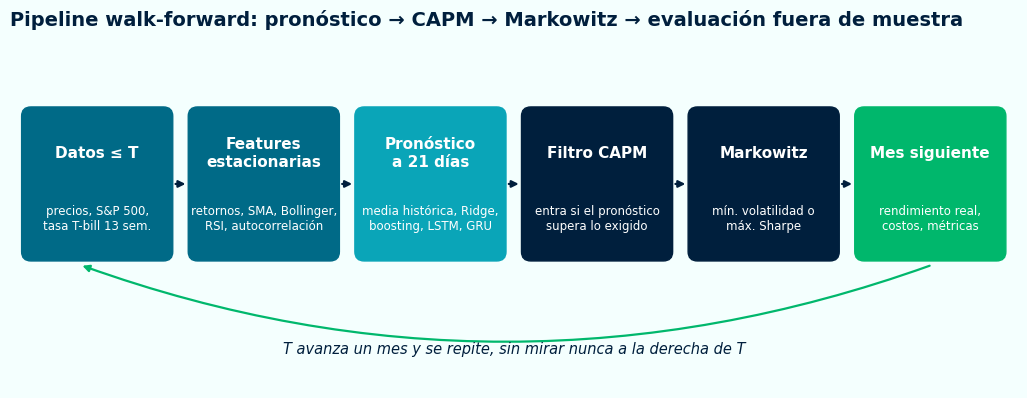

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.6); ax.axis('off')

cajas = [
    (0.2,  "Datos ≤ T",            "precios, S&P 500,\ntasa T-bill 13 sem.", C_WRONG),
    (2.35, "Features\nestacionarias", "retornos, SMA, Bollinger,\nRSI, autocorrelación", C_WRONG),
    (4.5,  "Pronóstico\na 21 días", "media histórica, Ridge,\nboosting, LSTM, GRU", C_TEAL),
    (6.65, "Filtro CAPM",          "entra si el pronóstico\nsupera lo exigido", C_DARK),
    (8.8,  "Markowitz",            "mín. volatilidad o\nmáx. Sharpe", C_DARK),
    (10.95,"Mes siguiente",        "rendimiento real,\ncostos, métricas", C_RIGHT),
]
for x, titulo, sub, color in cajas:
    ax.add_patch(FancyBboxPatch((x, 1.7), 1.85, 1.9, boxstyle="round,pad=0.05,rounding_size=0.12",
                                facecolor=color, edgecolor=color))
    ax.text(x + 0.925, 3.05, titulo, ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    ax.text(x + 0.925, 2.2, sub, ha='center', va='center', color='white', fontsize=8.5)
for i in range(len(cajas) - 1):
    x0 = cajas[i][0] + 1.9; x1 = cajas[i + 1][0] - 0.05
    ax.annotate("", xy=(x1, 2.65), xytext=(x0, 2.65),
                arrowprops=dict(arrowstyle="-|>", color=C_DARK, lw=1.6))
ax.annotate("", xy=(0.9, 1.6), xytext=(11.9, 1.6),
            arrowprops=dict(arrowstyle="-|>", color=C_RIGHT, lw=1.6, connectionstyle="arc3,rad=-0.18"))
ax.text(6.5, 0.45, "T avanza un mes y se repite, sin mirar nunca a la derecha de T",
        ha='center', color=C_DARK, fontsize=10.5, style='italic')
ax.set_title("Pipeline walk-forward: pronóstico → CAPM → Markowitz → evaluación fuera de muestra", loc='left')
plt.show()

## 1. Obtención de los datos: precios de activos

Datos abiertos de Yahoo Finance para diez acciones de alta capitalización:

- AAPL (Apple Inc.)
- MSFT (Microsoft Corporation)
- GOOGL (Alphabet Inc., Clase A)
- AMZN (Amazon.com Inc.)
- TSLA (Tesla, Inc.)
- META (Meta Platforms, Inc.)
- NFLX (Netflix, Inc.)
- NVDA (NVIDIA Corporation)
- JPM (JPMorgan Chase & Co.)
- JNJ (Johnson & Johnson)

Además se descargan dos series que el pipeline necesita para no inventar supuestos:

- **S&P 500 (^GSPC)** como proxy del mercado para calcular beta.
- **Tasa del T-bill a 13 semanas (^IRX)** como tasa libre de riesgo del periodo, en lugar de un 2% fijo que en 2023 y 2024 habría quedado muy por debajo de la tasa real del mercado.

Se recupera el histórico entre el 1 de enero de 2020 y el 1 de julio de 2024. Este rango queda fijo para que el notebook sea reproducible, si quieres datos más recientes solo cambia `FECHA_FINAL`.

In [ ]:
def descargar_cierres(tickers, start, end):
    """Descarga precios de cierre ajustados. auto_adjust=True hace que 'Close'
    ya incorpore dividendos y splits, que es el valor por defecto actual de
    yfinance; se declara explícito para que no dependa de la versión."""
    df = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    close = df['Close']
    if isinstance(close, pd.Series):
        close = close.to_frame(tickers if isinstance(tickers, str) else tickers[0])
    return close

precios_raw = descargar_cierres(SYMBOLS, FECHA_INICIAL, FECHA_FINAL)[SYMBOLS]
sp500_raw   = descargar_cierres('^GSPC', FECHA_INICIAL, FECHA_FINAL).iloc[:, 0]
irx_raw     = descargar_cierres('^IRX',  FECHA_INICIAL, FECHA_FINAL).iloc[:, 0]

# Calendario común: solo días en que cotizan las 10 acciones y el índice.
# La tasa se rellena hacia adelante porque el mercado de bonos cierra en
# algunos feriados en que la bolsa sí abre; nunca se rellena hacia atrás.
idx = precios_raw.dropna().index.intersection(sp500_raw.dropna().index)
precios = precios_raw.loc[idx]
sp500   = sp500_raw.loc[idx].rename('SP500')
irx     = irx_raw.reindex(idx).ffill()

assert precios.notna().all().all(), "Hay precios faltantes en el calendario común"
assert irx.notna().all(), "La tasa libre de riesgo tiene huecos al inicio de la serie"

rf_diaria = (irx / 100.0) / 252          # tasa anual en % convertida a rendimiento diario
ret_simple = precios.pct_change()         # rendimientos simples diarios, para portafolio y CAPM
ret_mkt    = sp500.pct_change()
logp       = np.log(precios)

print(f"Periodo: {idx[0].date()} → {idx[-1].date()}  |  {len(idx)} días hábiles  |  {precios.shape[1]} acciones")
precios.tail(3)

Periodo: 2020-01-02 → 2024-06-28  |  1130 días hábiles  |  10 acciones


Ticker,AAPL,MSFT,GOOGL,AMZN,TSLA,META,NFLX,NVDA,JPM,JNJ
Date,,,,,,,,,,
2024-06-26,211.236404,444.327484,182.355820,193.610001,196.369995,509.296539,67.768997,126.050972,188.425156,138.040359
2024-06-27,212.078400,445.005493,183.873123,197.850006,197.419998,515.688538,68.433998,123.647614,190.085770,137.081375
2024-06-28,208.631256,439.207733,180.640106,193.250000,197.880005,500.462860,67.487999,123.198868,193.034836,137.419830


## 2. Explicación de los datos

- **Precio de cierre ajustado.** El precio de cierre es el último precio al que se negoció la acción en la sesión. El ajustado además incorpora dividendos y splits, así un salto por split no se confunde con un movimiento real.
- **Rendimiento diario.** Cambio porcentual del precio de un día al siguiente. Es la unidad con la que trabajan CAPM y Markowitz.
- **Rendimiento logarítmico a 21 días.** Es lo que se va a pronosticar: cuánto sube o baja la acción en el mes siguiente a la fecha de decisión.
- **Tasa libre de riesgo.** Rendimiento anual del T-bill a 13 semanas. Se convierte a diario para restarla y obtener rendimientos en exceso.

La tabla de abajo resume cada acción en el periodo previo al backtest, que es lo único que un analista habría conocido el 1 de enero de 2023.

In [ ]:
pre = ret_simple.loc[:INICIO_BACKTEST].dropna()
resumen = pd.DataFrame({
    'Rend. anual medio': pre.mean() * 252,
    'Volatilidad anual': pre.std() * np.sqrt(252),
    'Peor día': pre.min(),
    'Mejor día': pre.max(),
    'Autocorr. lag 1': pre.apply(lambda s: s.autocorr(1)),
})
print(f"Tasa T-bill: mín {irx.min():.2f}%, máx {irx.max():.2f}%, al inicio del backtest {irx.loc[:INICIO_BACKTEST].iloc[-1]:.2f}%")
resumen.style.format({'Rend. anual medio': '{:.1%}', 'Volatilidad anual': '{:.1%}',
                      'Peor día': '{:.1%}', 'Mejor día': '{:.1%}', 'Autocorr. lag 1': '{:.3f}'})

Tasa T-bill: mín -0.10%, máx 5.35%, al inicio del backtest 4.26%


,Rend. anual medio,Volatilidad anual,Peor día,Mejor día,Autocorr. lag 1
Ticker,,,,,
AAPL,25.8%,36.9%,-12.9%,12.0%,-0.151
MSFT,20.4%,34.8%,-14.7%,14.2%,-0.230
GOOGL,14.4%,34.5%,-11.6%,9.2%,-0.148
AMZN,3.6%,39.1%,-14.0%,13.5%,-0.031
TSLA,74.7%,72.2%,-21.1%,19.9%,-0.008
META,-6.3%,48.7%,-26.4%,17.6%,-0.067
NFLX,10.4%,51.9%,-35.1%,16.9%,-0.062
NVDA,45.5%,56.0%,-18.5%,17.2%,-0.127
JPM,8.5%,37.9%,-15.0%,18.0%,-0.150


## 3. Análisis exploratorio

Tres gráficas, cada una responde una pregunta que después condiciona una decisión.

- **¿Cómo se comparan los activos entre sí?** Precios en base 100 para ponerlos en la misma escala.
- **¿Hay diversificación posible?** La matriz de correlación es el insumo central de Markowitz. Correlaciones bajas significan que combinar activos reduce el riesgo.
- **¿Hay algo que pronosticar?** Si la autocorrelación de los rendimientos diarios es casi cero, ningún modelo va a sacar mucha señal del precio pasado, y la vara con la que se mide cualquier modelo tiene que ser una alternativa simple.

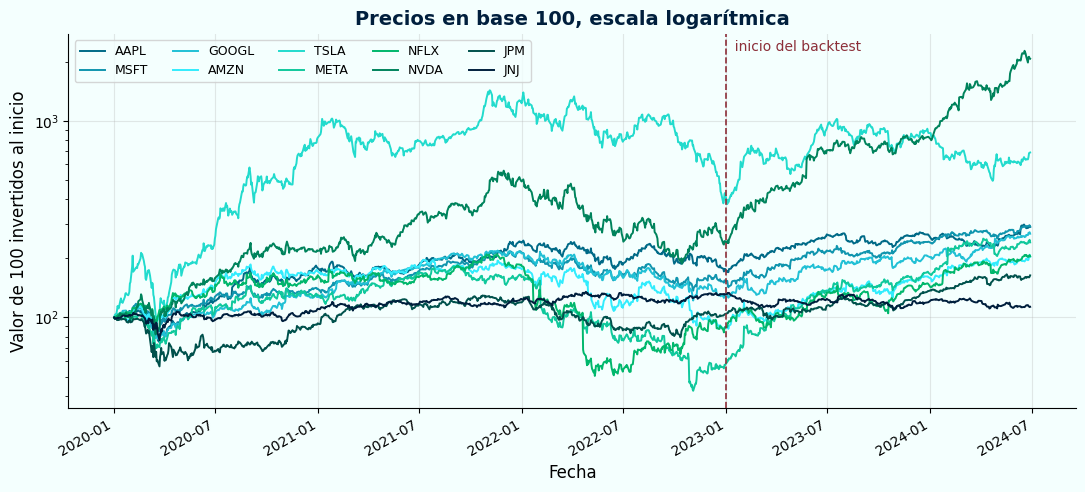

In [ ]:
base100 = precios / precios.iloc[0] * 100
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_prop_cycle(color=brand_colors(len(SYMBOLS)))
base100.plot(ax=ax, linewidth=1.4)
ax.axvline(pd.Timestamp(INICIO_BACKTEST), color=C_ERROR, linestyle='--', linewidth=1.2)
ax.text(pd.Timestamp(INICIO_BACKTEST), ax.get_ylim()[1] * 0.95, '  inicio del backtest', color=C_ERROR, fontsize=10)
ax.set_yscale('log')
ax.set_title('Precios en base 100, escala logarítmica')
ax.set_xlabel('Fecha'); ax.set_ylabel('Valor de 100 invertidos al inicio')
ax.legend(ncol=5, fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

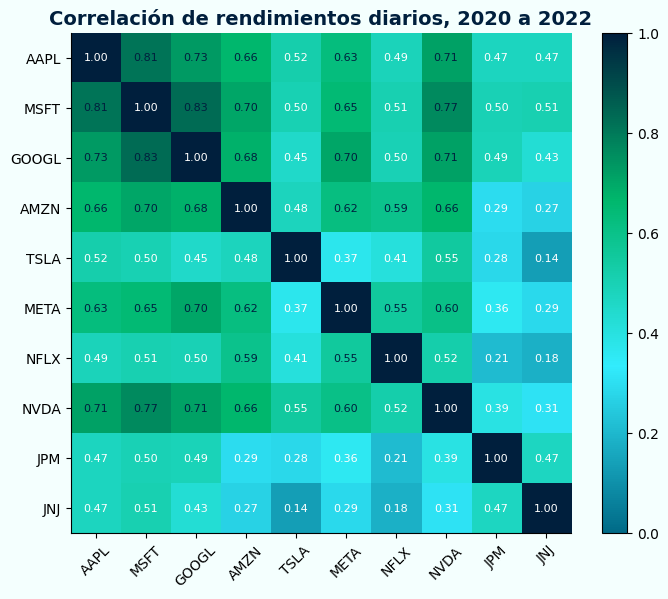

In [ ]:
corr = pre.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.values, cmap=_brand_cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(SYMBOLS))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(SYMBOLS))); ax.set_yticklabels(corr.columns)
for i in range(len(SYMBOLS)):
    for j in range(len(SYMBOLS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center', fontsize=8,
                color='white' if corr.values[i, j] < 0.55 or corr.values[i, j] > 0.9 else C_DARK)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlación de rendimientos diarios, 2020 a 2022')
plt.show()

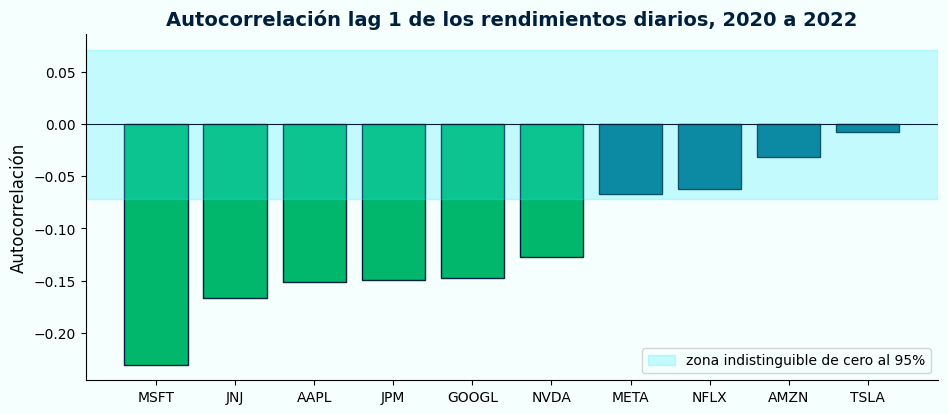

In [ ]:
n_obs = len(pre)
banda = 1.96 / np.sqrt(n_obs)
ac = resumen['Autocorr. lag 1'].sort_values()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(ac.index, ac.values, color=[C_RIGHT if abs(v) > banda else C_WRONG for v in ac.values], edgecolor=C_DARK)
ax.axhspan(-banda, banda, color=C_ACCENT, alpha=0.25, label='zona indistinguible de cero al 95%')
ax.axhline(0, color=C_DARK, linewidth=0.8)
ax.set_title('Autocorrelación lag 1 de los rendimientos diarios, 2020 a 2022')
ax.set_ylabel('Autocorrelación')
ax.legend()
plt.show()

Lo que dice la última gráfica marca todo lo que sigue: la memoria de corto plazo de los rendimientos es débil y, en varias acciones, indistinguible de cero. Por eso cada modelo de este notebook se compara contra dos alternativas que no aprenden nada, **la media histórica**, que es el insumo clásico de Markowitz, y **el paseo aleatorio**, que pronostica rendimiento cero. Si un modelo no les gana a esas dos, su complejidad no se justifica.

## 4. Lo que cambió respecto a la primera versión de este pipeline

La primera versión de este notebook pronosticaba **el nivel del precio** y calculaba el rendimiento esperado con las predicciones de los mismos 30 días de prueba. Tenía dos problemas que no se veían en las métricas, y se dejan documentados porque son el tipo de error que más se repite en proyectos de este tipo.

- **Precios fuera de rango.** El escalado MinMax se ajusta con el entrenamiento. Cuando el precio de prueba supera el máximo histórico, la red no sabe extrapolar y su predicción se queda plana. En NVDA la predicción quedó en unos 88 dólares mientras el precio real subía de 94 a 135. La gráfica de abajo muestra por qué.
- **Información del futuro en el rendimiento esperado.** Cada predicción de un día usaba los precios reales de los días anteriores del mismo periodo de prueba, así que el "rendimiento esperado" del mes ya contenía casi todo el mes. Ese número no lo habría tenido nadie el día que tenía que invertir.

La corrección es la base de esta versión: se pronostica el **rendimiento a 21 días**, que no tiene tendencia y se mantiene en rango, y se pronostica **desde la fecha de decisión hacia adelante**, con datos que solo llegan hasta ese día.

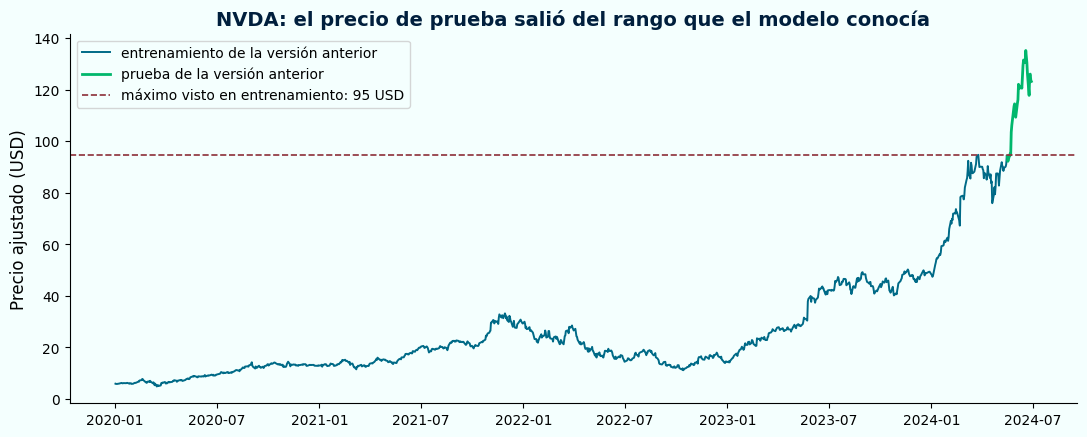

Rango del rendimiento diario de NVDA, entrenamiento: -0.204 a 0.218
Rango del rendimiento diario de NVDA, prueba:        -0.069 a 0.089


In [ ]:
nvda = precios['NVDA']
corte = len(nvda) - 30
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(nvda.index[:corte], nvda.values[:corte], color=C_WRONG, linewidth=1.4, label='entrenamiento de la versión anterior')
ax.plot(nvda.index[corte:], nvda.values[corte:], color=C_RIGHT, linewidth=2, label='prueba de la versión anterior')
ax.axhline(nvda.values[:corte].max(), color=C_ERROR, linestyle='--', linewidth=1.2,
           label=f'máximo visto en entrenamiento: {nvda.values[:corte].max():.0f} USD')
ax.set_title('NVDA: el precio de prueba salió del rango que el modelo conocía')
ax.set_ylabel('Precio ajustado (USD)')
ax.legend(loc='upper left')
plt.show()

lr_nvda = logp['NVDA'].diff()
print(f"Rango del rendimiento diario de NVDA, entrenamiento: {lr_nvda.iloc[:corte].min():.3f} a {lr_nvda.iloc[:corte].max():.3f}")
print(f"Rango del rendimiento diario de NVDA, prueba:        {lr_nvda.iloc[corte:].min():.3f} a {lr_nvda.iloc[corte:].max():.3f}")

## 5. Diseño de la evaluación: walk-forward con purga

- **Fechas de decisión.** Desde enero de 2023, una cada 21 días hábiles. En cada una se pronostica, se filtra, se optimiza y se invierte por los 21 días siguientes.
- **Purga.** El objetivo de un día es el rendimiento de los 21 días siguientes. Una muestra solo entra al entrenamiento si esos 21 días ya terminaron antes de T. Sin esto, el modelo entrenaría con rendimientos que todavía no ocurrieron.
- **Embargo en la validación.** La validación interna, que decide cuándo detener el entrenamiento, es el último 20% del periodo de entrenamiento, separado por 21 días para que ningún objetivo se traslape entre las dos partes. El periodo de prueba nunca se usa para validar.
- **Reentrenamiento trimestral.** Los modelos se reentrenan cada tres fechas de decisión. Entre reentrenamientos se usa el último modelo con los datos nuevos de entrada, que es lo que haría un analista en la práctica.

In [ ]:
p_inicio = idx.searchsorted(pd.Timestamp(INICIO_BACKTEST))
REBAL = list(range(p_inicio, len(idx) - H, H))           # posiciones de las fechas de decisión
RETRAIN = REBAL[::RETRAIN_EVERY]                         # posiciones donde se reentrena

assert REBAL[0] - max(LOOKBACK_COV, LOOKBACK_BETA) >= 1, "No hay historia suficiente antes del backtest"
assert all(p + H <= len(idx) - 1 for p in REBAL), "Algún periodo de tenencia se sale de los datos"

print(f"{len(REBAL)} fechas de decisión: {idx[REBAL[0]].date()} a {idx[REBAL[-1]].date()}")
print(f"{len(RETRAIN)} reentrenamientos por modelo y por acción")
print(f"Periodo fuera de muestra evaluado: {idx[REBAL[0] + 1].date()} a {idx[REBAL[-1] + H].date()}")

17 fechas de decisión: 2023-01-03 a 2024-05-06
6 reentrenamientos por modelo y por acción
Periodo fuera de muestra evaluado: 2023-01-04 a 2024-06-05


## 6. Predicción de rendimientos: features

### Decisión: ¿solo precio de cierre o con indicadores técnicos?

**¿Solo precio de cierre o con indicadores técnicos?**

Un modelo que solo ve el precio de cierre es más simple y tiene menos riesgo de sobreajuste, pero pierde señales de momentum y volatilidad. Agregar indicadores técnicos da al modelo más contexto, a cambio de más features que calcular y más filas perdidas por las ventanas móviles.

Aquí las dos opciones se corren de verdad. Para que ambas sean comparables, el precio entra como rendimiento diario y los indicadores se expresan en forma relativa al precio, así ninguna feature crece sin límite como lo hacía el precio en la versión anterior:

1. **SMA de 20 días,** como distancia del precio a su promedio: `precio / SMA − 1`.
2. **Bandas de Bollinger de 20 días y 2 desviaciones,** como posición dentro de las bandas, %B, y como ancho relativo de las bandas.
3. **RSI de 14 días,** escalado de 0 a 1.
4. **Autocorrelación de rezago 1 en ventana móvil de 10 días,** calculada sobre los rendimientos, un valor por día.

Con menos de un año de historial, agregar indicadores es justo la opción que corre más riesgo de dejarte con muy pocas filas útiles para entrenar, porque cada ventana móvil consume filas al principio de la serie.

Explora esta decisión, con el resultado de ambas opciones, en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_indicadores)

In [ ]:
FEATS_PRECIO = ['ret_1']
FEATS_IND    = ['ret_1', 'sma_ratio', 'bb_pctb', 'bb_width', 'rsi_14', 'autocorr_10']

def calcular_features(close):
    """Todas las ventanas miran solo hacia atrás: el valor del día t usa
    datos hasta t. Por eso se pueden calcular sobre la serie completa sin
    filtrar el futuro, y el checklist final lo comprueba recalculando sobre
    series recortadas."""
    f = pd.DataFrame(index=close.index)
    r = np.log(close).diff()
    f['ret_1'] = r
    sma = close.rolling(20).mean()
    std = close.rolling(20).std()
    upper, lower = sma + 2 * std, sma - 2 * std
    f['sma_ratio'] = close / sma - 1
    f['bb_pctb']   = (close - lower) / (upper - lower)
    f['bb_width']  = (upper - lower) / sma
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    f['rsi_14'] = (100 - 100 / (1 + gain / loss)) / 100
    f['autocorr_10'] = r.rolling(10).apply(lambda s: pd.Series(s).autocorr(lag=1), raw=True)
    return f.replace([np.inf, -np.inf], np.nan)

def calcular_objetivo(close, h=H):
    """Rendimiento logarítmico de t a t+h. En el día t todavía no se conoce:
    solo existe en t+h, y por eso la purga del entrenamiento lo respeta."""
    lc = np.log(close)
    return lc.shift(-h) - lc

FEATURES = {s: calcular_features(precios[s]) for s in SYMBOLS}
OBJETIVO = {s: calcular_objetivo(precios[s]) for s in SYMBOLS}

primer_valido_precio = FEATURES['AAPL'][FEATS_PRECIO].dropna().index[0]
primer_valido_ind    = FEATURES['AAPL'][FEATS_IND].dropna().index[0]
print("Primer día utilizable, solo precio:  ", primer_valido_precio.date())
print("Primer día utilizable, con indicadores:", primer_valido_ind.date())
print("Filas perdidas por las ventanas móviles:",
      FEATURES['AAPL'].index.get_loc(primer_valido_ind) - FEATURES['AAPL'].index.get_loc(primer_valido_precio))
FEATURES['AAPL'][FEATS_IND].describe().T[['mean', 'std', 'min', 'max']]

Primer día utilizable, solo precio:   2020-01-03
Primer día utilizable, con indicadores: 2020-01-30
Filas perdidas por las ventanas móviles: 18


,mean,std,min,max
ret_1,0.000939,0.020581,-0.137708,0.113157
sma_ratio,0.009131,0.046420,-0.168029,0.147493
bb_pctb,0.575826,0.327447,-0.260390,1.370145
bb_width,0.128782,0.058040,0.032976,0.362568
rsi_14,0.545923,0.170513,0.031798,0.932418
autocorr_10,-0.122656,0.292054,-0.930479,0.867402


## 7. Modelos candidatos

### Decisión: ¿cuántas capas LSTM y cuántas unidades?

**¿Cuántas capas LSTM y cuántas unidades?**

Una sola capa de 50 unidades entrena más rápido y es menos propensa a sobreajustar, pero puede no capturar patrones más complejos. Tres capas apiladas con Dropout dan más capacidad a costa de más tiempo de entrenamiento.

El diseño de la comparación aísla una variable a la vez:

- **LSTM de 3 capas** es la arquitectura original del proyecto: 3 × 50 unidades, Dropout 0.2 y 0.1, salida con regularización L2.
- **LSTM de 1 capa** cambia solo la profundidad.
- **GRU de 3 capas** cambia solo el tipo de celda. La GRU tiene menos parámetros que la LSTM y suele entrenar más rápido con resultados parecidos.
- **Ridge** y **Gradient Boosting** reciben exactamente la misma ventana de 20 días, aplanada. Si una red recurrente no le gana a un modelo lineal con la misma información, la memoria de la red no está aportando.
- **Media histórica** y **paseo aleatorio** son las dos vallas mínimas descritas arriba.

Si quisieras probar otra arquitectura, por ejemplo un Transformer de series de tiempo, `construir_rnn` es la única pieza que reemplazas, el resto del pipeline no se entera, porque solo espera un rendimiento esperado por activo.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_arquitectura)

In [ ]:
def construir_rnn(tipo):
    """Sin input_shape: Keras construye el modelo con la forma del primer lote."""
    if tipo == 'LSTM-3':
        capas = [LSTM(50, return_sequences=True), LSTM(50, return_sequences=True), Dropout(0.2),
                 LSTM(50), Dropout(0.1), Dense(1, kernel_regularizer=L2(0.01))]
    elif tipo == 'LSTM-1':
        capas = [LSTM(50), Dropout(0.2), Dense(1, kernel_regularizer=L2(0.01))]
    elif tipo == 'GRU-3':
        capas = [GRU(50, return_sequences=True), GRU(50, return_sequences=True), Dropout(0.2),
                 GRU(50), Dropout(0.1), Dense(1, kernel_regularizer=L2(0.01))]
    else:
        raise ValueError(tipo)
    model = Sequential(capas)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# nombre visible → (familia, arquitectura, features)
MODELOS = {
    'Ridge':                 ('tabular', 'ridge',  FEATS_IND),
    'Gradient Boosting':     ('tabular', 'hgb',    FEATS_IND),
    'LSTM 1 capa':           ('rnn',     'LSTM-1', FEATS_IND),
    'LSTM 3 capas':          ('rnn',     'LSTM-3', FEATS_IND),
    'GRU 3 capas':           ('rnn',     'GRU-3',  FEATS_IND),
    'LSTM 3 capas, solo precio': ('rnn', 'LSTM-3', FEATS_PRECIO),
}
BASELINES = ['Media histórica', 'Paseo aleatorio']
MODELO_PROYECTO = 'LSTM 3 capas'   # la elección original del artículo

n_rnn = sum(1 for v in MODELOS.values() if v[0] == 'rnn')
print(f"Redes a entrenar: {n_rnn} arquitecturas × {len(SYMBOLS)} acciones × {len(RETRAIN)} reentrenamientos = {n_rnn * len(SYMBOLS) * len(RETRAIN)}")

Redes a entrenar: 4 arquitecturas × 10 acciones × 6 reentrenamientos = 240


In [ ]:
LOG_ENTRENAMIENTO = []   # evidencia para el checklist metodológico

def ventanas_validas(F, window):
    """valid[t] es True si las filas t-window+1..t no tienen NaN."""
    bad = np.isnan(F).any(axis=1).astype(int)
    cum = np.concatenate([[0], np.cumsum(bad)])
    valid = np.zeros(len(F), dtype=bool)
    for t in range(window - 1, len(F)):
        valid[t] = (cum[t + 1] - cum[t + 1 - window]) == 0
    return valid

def armar_X(Fs, posiciones, window):
    return np.stack([Fs[t - window + 1:t + 1] for t in posiciones])

def entrenar_y_predecir(nombre, activo, p_T, pred_pos, guardar_historia=False):
    """Entrena con información disponible hasta p_T y pronostica en pred_pos (todas ≥ p_T)."""
    familia, arq, cols = MODELOS[nombre]
    F = FEATURES[activo][cols].values.astype(float)
    y = OBJETIVO[activo].values.astype(float)
    valid = ventanas_validas(F, WINDOW)

    # Purga: el objetivo de t termina en t+H y tiene que haber ocurrido a más tardar en T.
    pos_train = [t for t in range(len(F)) if valid[t] and t + H <= p_T and not np.isnan(y[t])]
    n_val = int(len(pos_train) * VAL_FRAC)
    pos_val = pos_train[-n_val:]
    pos_fit = [t for t in pos_train[:-n_val] if t + H < pos_val[0]]   # embargo de H días

    # Escalado ajustado solo con las filas que entran al ajuste del modelo.
    fin_scaler = pos_fit[-1]
    filas_fit = F[:fin_scaler + 1][~np.isnan(F[:fin_scaler + 1]).any(axis=1)]
    scaler = StandardScaler().fit(filas_fit)
    assert np.allclose(scaler.mean_, filas_fit.mean(axis=0)), "El scaler no corresponde a las filas de entrenamiento"
    Fs = np.where(np.isnan(F), np.nan, (F - scaler.mean_) / scaler.scale_)
    y_mu, y_sd = y[pos_fit].mean(), y[pos_fit].std()

    X_fit, X_val = armar_X(Fs, pos_fit, WINDOW), armar_X(Fs, pos_val, WINDOW)
    X_pred = armar_X(Fs, pred_pos, WINDOW)
    assert not np.isnan(X_pred).any(), f"Ventana de pronóstico incompleta para {activo}"
    yz_fit, yz_val = (y[pos_fit] - y_mu) / y_sd, (y[pos_val] - y_mu) / y_sd

    t0 = time.time()
    historia, epocas = None, None
    if familia == 'tabular':
        a = lambda X: X.reshape(len(X), -1)
        X_all = np.concatenate([X_fit, X_val]); y_all = np.concatenate([yz_fit, yz_val])
        if arq == 'ridge':
            # alfa elegido con la validación interna, después se reajusta con fit + val
            alfas = [0.1, 1, 10, 100, 1000]
            errs = [np.mean((Ridge(alpha=al).fit(a(X_fit), yz_fit).predict(a(X_val)) - yz_val) ** 2) for al in alfas]
            modelo = Ridge(alpha=alfas[int(np.argmin(errs))]).fit(a(X_all), y_all)
        else:
            # número de árboles elegido con la validación temporal, no con una partición aleatoria
            hgb = lambda n: HistGradientBoostingRegressor(max_iter=n, learning_rate=0.05, max_depth=3,
                                                          early_stopping=False, random_state=SEED)
            prueba = hgb(300).fit(a(X_fit), yz_fit)
            errs = [np.mean((pz - yz_val) ** 2) for pz in prueba.staged_predict(a(X_val))]
            modelo = hgb(int(np.argmin(errs)) + 1).fit(a(X_all), y_all)
        pred_z = modelo.predict(a(X_pred))
    else:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        modelo = construir_rnn(arq)
        es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
        h = modelo.fit(X_fit, yz_fit, validation_data=(X_val, yz_val), epochs=EPOCHS_MAX,
                       batch_size=BATCH_SIZE, callbacks=[es], verbose=0, shuffle=True)
        historia = h.history if guardar_historia else None
        epocas = len(h.history['loss'])
        pred_z = modelo.predict(X_pred, verbose=0).flatten()

    LOG_ENTRENAMIENTO.append({
        'modelo': nombre, 'activo': activo, 'p_T': p_T,
        'fin_scaler': fin_scaler, 'fin_objetivo_train': max(pos_train) + H,
        'inicio_val': pos_val[0], 'fin_fit_mas_H': pos_fit[-1] + H,
        'min_pred_pos': min(pred_pos), 'n_fit': len(pos_fit), 'n_val': len(pos_val),
        'epocas': epocas, 'segundos': time.time() - t0,
    })
    pred = pred_z * y_sd + y_mu
    return (pred, historia) if guardar_historia else pred

### Un modelo de muestra antes del backtest completo

- Se entrena el LSTM de 3 capas para AAPL en la primera fecha de decisión, solo con datos anteriores a enero de 2023.
- La curva compara la pérdida de entrenamiento contra la de **validación interna**. El periodo de prueba no participa.
- El entrenamiento se detiene solo cuando la validación deja de mejorar, y se conservan los pesos de la mejor época.

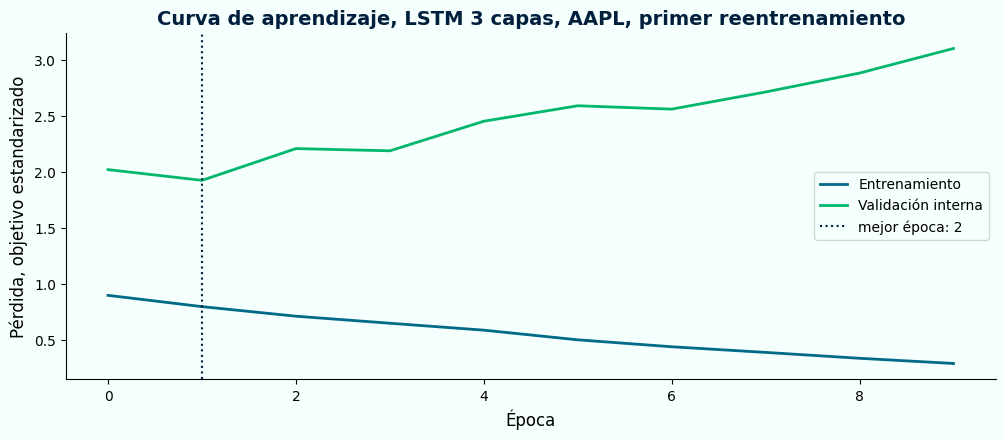

Pronóstico de rendimiento a 21 días para AAPL desde 2023-01-03: +0.50%


In [ ]:
_pred_demo, hist_demo = entrenar_y_predecir(MODELO_PROYECTO, 'AAPL', RETRAIN[0], [RETRAIN[0]], guardar_historia=True)
LOG_ENTRENAMIENTO.pop()   # la demo no forma parte del backtest

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hist_demo['loss'], color=C_WRONG, linewidth=2, label='Entrenamiento')
ax.plot(hist_demo['val_loss'], color=C_RIGHT, linewidth=2, label='Validación interna')
best = int(np.argmin(hist_demo['val_loss']))
ax.axvline(best, color=C_DARK, linestyle=':', label=f'mejor época: {best + 1}')
ax.set_title('Curva de aprendizaje, LSTM 3 capas, AAPL, primer reentrenamiento')
ax.set_xlabel('Época'); ax.set_ylabel('Pérdida, objetivo estandarizado')
ax.legend()
plt.show()
print(f"Pronóstico de rendimiento a 21 días para AAPL desde {idx[RETRAIN[0]].date()}: {np.expm1(_pred_demo[0]):+.2%}")

Si la validación deja de bajar en las primeras épocas, no es un error del código: es la señal honesta de que hay poca estructura que aprender en el precio pasado, lo mismo que anticipaba la gráfica de autocorrelación. El backtest de abajo mide si esa poca estructura alcanza para ganarle a las alternativas simples.

### Backtest de pronósticos: todos los modelos, todas las acciones, todas las fechas

- Cada modelo produce un pronóstico por acción en cada fecha de decisión, usando solo el modelo entrenado en el último reentrenamiento anterior o igual a esa fecha.
- Los resultados se guardan en disco. Si vuelves a correr el notebook con la misma configuración, esta celda los carga en vez de entrenar todo otra vez.

In [ ]:
CONFIG = dict(SYMBOLS=SYMBOLS, FECHA_INICIAL=FECHA_INICIAL, FECHA_FINAL=FECHA_FINAL, INICIO_BACKTEST=INICIO_BACKTEST,
              H=H, WINDOW=WINDOW, RETRAIN_EVERY=RETRAIN_EVERY, VAL_FRAC=VAL_FRAC, EPOCHS_MAX=EPOCHS_MAX,
              PATIENCE=PATIENCE, BATCH_SIZE=BATCH_SIZE, SEED=SEED, MODELOS=list(MODELOS), n_dias=len(idx))
CACHE = f"pronosticos_{hashlib.md5(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:10]}.pkl"

def bloques_de_prediccion():
    """Asigna a cada reentrenamiento las fechas de decisión que le tocan."""
    for k, p_T in enumerate(RETRAIN):
        siguiente = RETRAIN[k + 1] if k + 1 < len(RETRAIN) else len(idx)
        yield p_T, [p for p in REBAL if p_T <= p < siguiente]

if os.path.exists(CACHE):
    with open(CACHE, 'rb') as fh:
        PRONOSTICOS, LOG_ENTRENAMIENTO = pickle.load(fh)
    print("Pronósticos cargados de", CACHE)
else:
    filas = []
    t_inicio = time.time()
    for nombre in MODELOS:
        t_modelo = time.time()
        for activo in SYMBOLS:
            for p_T, pred_pos in bloques_de_prediccion():
                preds = entrenar_y_predecir(nombre, activo, p_T, pred_pos)
                for p, yhat in zip(pred_pos, preds):
                    filas.append((idx[p], activo, nombre, float(yhat)))
        print(f"{nombre:28s} listo en {(time.time() - t_modelo) / 60:5.1f} min")
    PRONOSTICOS = pd.DataFrame(filas, columns=['fecha', 'activo', 'modelo', 'pred'])
    with open(CACHE, 'wb') as fh:
        pickle.dump((PRONOSTICOS, LOG_ENTRENAMIENTO), fh)
    print(f"Total: {(time.time() - t_inicio) / 60:.1f} min. Guardado en {CACHE}")

# Baselines: no se entrenan, se calculan con datos hasta T.
lr_diario = logp.diff()
filas = []
for p in REBAL:
    for activo in SYMBOLS:
        media = lr_diario[activo].iloc[p - LOOKBACK_COV + 1:p + 1].mean() * H
        filas.append((idx[p], activo, 'Media histórica', float(media)))
        filas.append((idx[p], activo, 'Paseo aleatorio', 0.0))
PRONOSTICOS = pd.concat([PRONOSTICOS, pd.DataFrame(filas, columns=PRONOSTICOS.columns)], ignore_index=True)

# Rendimiento real a 21 días, solo para evaluar, nunca como insumo.
PRONOSTICOS['real'] = [OBJETIVO[a].loc[f] for a, f in zip(PRONOSTICOS['activo'], PRONOSTICOS['fecha'])]
assert PRONOSTICOS['real'].notna().all()

# Tabla fecha × acción por modelo, para consultar rápido el pronóstico de una fecha.
PRED = {m: g.pivot(index='fecha', columns='activo', values='pred')[SYMBOLS] for m, g in PRONOSTICOS.groupby('modelo')}
def mu_de(modelo, p):
    """Rendimiento esperado simple a 21 días de cada acción, pronosticado en la fecha p."""
    return np.expm1(PRED[modelo].loc[idx[p]])

PRONOSTICOS.head()

Ridge                        listo en   0.0 min
Gradient Boosting            listo en   0.5 min
LSTM 1 capa                  listo en   4.5 min
LSTM 3 capas                 listo en   7.4 min
GRU 3 capas                  listo en   8.1 min
LSTM 3 capas, solo precio    listo en   9.6 min
Total: 30.1 min. Guardado en pronosticos_f391c179fe.pkl


,fecha,activo,modelo,pred,real
0,2023-01-03,AAPL,Ridge,-0.002417,0.187213
1,2023-02-02,AAPL,Ridge,0.040760,0.021287
2,2023-03-06,AAPL,Ridge,0.030398,0.073908
3,2023-04-04,AAPL,Ridge,0.008710,0.000965
4,2023-05-04,AAPL,Ridge,0.002661,0.081281


## 8. Evaluación, capa técnica: ¿qué modelo pronostica mejor?

Cuatro métricas, porque cada una responde algo distinto:

- **MAE**, error absoluto medio del rendimiento a 21 días. Es la más fácil de leer.
- **R² fuera de muestra contra paseo aleatorio.** `1 − error del modelo / error de pronosticar cero`. Es la métrica estándar en la literatura de predicción de rendimientos. Un valor negativo significa que pronosticar cero habría sido mejor.
- **Acierto de dirección.** Qué tan seguido el modelo acierta si la acción sube o baja.
- **IC, coeficiente de información.** Correlación de rangos entre pronóstico y resultado entre las 10 acciones de cada fecha. Es la que más le importa a un portafolio: no hace falta acertar el número exacto, hace falta ordenar bien qué acción va a rendir más.

In [ ]:
def metricas_pronostico(df):
    err = df['pred'] - df['real']
    sse0 = (df['real'] ** 2).sum()
    ic_fecha = df.groupby('fecha').apply(
        lambda g: spearmanr(g['pred'], g['real'])[0] if g['pred'].nunique() > 1 else np.nan)
    return pd.Series({
        'MAE': err.abs().mean(),
        'R² vs paseo aleatorio': 1 - (err ** 2).sum() / sse0,
        'Acierto de dirección': (np.sign(df['pred']) == np.sign(df['real'])).mean() if df['pred'].abs().sum() > 0 else np.nan,
        'IC medio': ic_fecha.mean(),
        'IC t-stat': ic_fecha.mean() / ic_fecha.std() * np.sqrt(ic_fecha.notna().sum()) if ic_fecha.notna().sum() > 2 else np.nan,
    })

ORDEN = BASELINES + list(MODELOS)
MET_PRON = PRONOSTICOS.groupby('modelo').apply(metricas_pronostico).loc[ORDEN]
seg = pd.DataFrame(LOG_ENTRENAMIENTO).groupby('modelo')['segundos'].sum()
MET_PRON['Minutos de entrenamiento'] = [seg.get(m, 0) / 60 for m in MET_PRON.index]
MET_PRON.style.format({'MAE': '{:.2%}', 'R² vs paseo aleatorio': '{:+.3f}', 'Acierto de dirección': '{:.1%}',
                       'IC medio': '{:+.3f}', 'IC t-stat': '{:+.2f}', 'Minutos de entrenamiento': '{:.1f}'}, na_rep='—')

/tmp/ipykernel_13144/2103230337.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_fecha = df.groupby('fecha').apply(
/tmp/ipykernel_13144/2103230337.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_fecha = df.groupby('fecha').apply(
/tmp/ipykernel_13144/2103230337.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future versio

,MAE,R² vs paseo aleatorio,Acierto de dirección,IC medio,IC t-stat,Minutos de entrenamiento
modelo,,,,,,
Media histórica,8.35%,-0.098,54.7%,+0.065,+0.57,0.0
Paseo aleatorio,8.35%,+0.000,—,—,—,0.0
Ridge,8.39%,+0.013,55.9%,+0.072,+0.95,0.0
Gradient Boosting,8.13%,+0.064,60.0%,-0.065,-1.13,0.5
LSTM 1 capa,8.53%,+0.052,54.1%,+0.034,+0.42,4.5
LSTM 3 capas,8.81%,-0.046,55.3%,-0.010,-0.11,7.4
GRU 3 capas,8.81%,+0.028,54.1%,-0.000,-0.00,8.1
"LSTM 3 capas, solo precio",8.09%,+0.155,55.3%,+0.077,+0.97,9.6


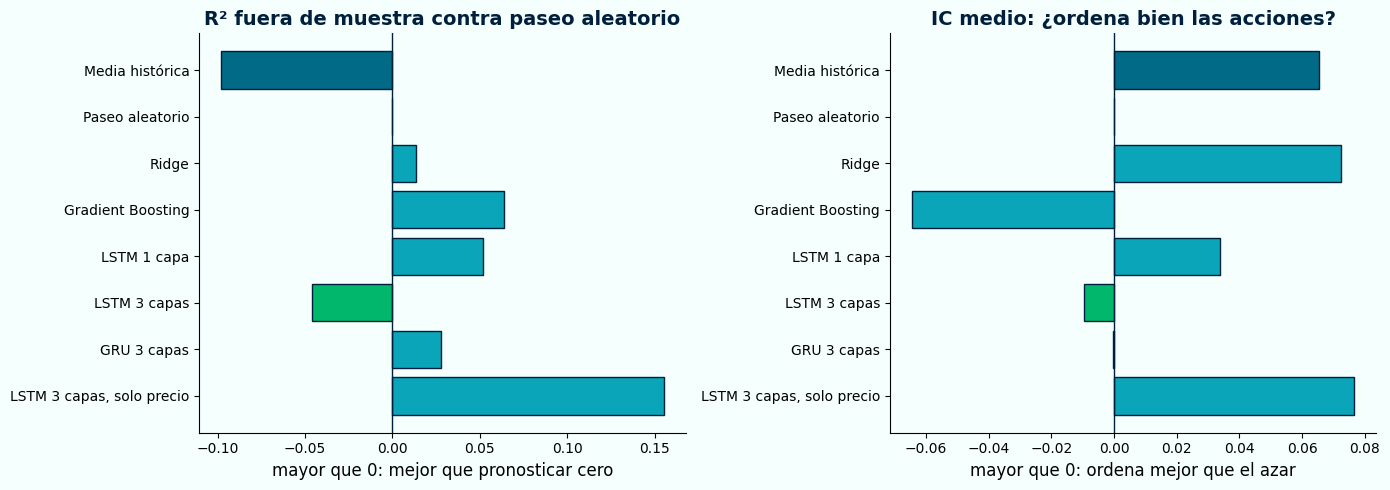

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = MET_PRON.index.tolist()
col = lambda m: C_WRONG if m in BASELINES else (C_RIGHT if m == MODELO_PROYECTO else C_TEAL)
r2 = MET_PRON['R² vs paseo aleatorio']
axes[0].barh(orden, r2, color=[col(m) for m in orden], edgecolor=C_DARK)
axes[0].axvline(0, color=C_DARK, linewidth=1)
axes[0].set_title('R² fuera de muestra contra paseo aleatorio')
axes[0].set_xlabel('mayor que 0: mejor que pronosticar cero')
axes[0].invert_yaxis()
ic = MET_PRON['IC medio'].fillna(0)
axes[1].barh(orden, ic, color=[col(m) for m in orden], edgecolor=C_DARK)
axes[1].axvline(0, color=C_DARK, linewidth=1)
axes[1].set_title('IC medio: ¿ordena bien las acciones?')
axes[1].set_xlabel('mayor que 0: ordena mejor que el azar')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### Resultado de las decisiones del modelo

Las dos decisiones del Explorador que tocan al modelo, leídas directamente de la tabla anterior.

- **¿Solo precio o con indicadores?** Compara `LSTM 3 capas, solo precio` contra `LSTM 3 capas`. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_indicadores)
- **¿Cuántas capas?** Compara `LSTM 1 capa`, `LSTM 3 capas` y `GRU 3 capas`, y las tres contra `Ridge`, que tiene la misma información sin memoria. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_arquitectura)

In [ ]:
d1 = MET_PRON.loc[['LSTM 3 capas, solo precio', 'LSTM 3 capas']]
d2 = MET_PRON.loc[['LSTM 1 capa', 'LSTM 3 capas', 'GRU 3 capas', 'Ridge']]
print("Decisión: ¿solo precio o con indicadores?")
display(d1.style.format('{:.3f}', na_rep='—'))
print("Decisión: ¿cuántas capas y qué celda?")
display(d2.style.format('{:.3f}', na_rep='—'))

Decisión: ¿solo precio o con indicadores?


,MAE,R² vs paseo aleatorio,Acierto de dirección,IC medio,IC t-stat,Minutos de entrenamiento
modelo,,,,,,
"LSTM 3 capas, solo precio",0.081,0.155,0.553,0.077,0.970,9.624
LSTM 3 capas,0.088,-0.046,0.553,-0.010,-0.106,7.434


Decisión: ¿cuántas capas y qué celda?


,MAE,R² vs paseo aleatorio,Acierto de dirección,IC medio,IC t-stat,Minutos de entrenamiento
modelo,,,,,,
LSTM 1 capa,0.085,0.052,0.541,0.034,0.421,4.450
LSTM 3 capas,0.088,-0.046,0.553,-0.010,-0.106,7.434
GRU 3 capas,0.088,0.028,0.541,-0.000,-0.004,8.093
Ridge,0.084,0.013,0.559,0.072,0.947,0.014


## 9. Selección de activos con CAPM

El Modelo de Valoración de Activos de Capital (CAPM) dice cuánto rendimiento hay que exigirle a una acción por el riesgo de mercado que trae:

`rendimiento exigido = tasa libre de riesgo + beta × prima de mercado`

La regla de filtro es comparar ese mínimo contra lo que el modelo pronostica. **Una acción entra al optimizador solo si su rendimiento pronosticado supera su rendimiento exigido**, es decir, si tiene alfa positivo. Todo se mide en el mismo horizonte de 21 días, y beta, la tasa y la prima de mercado se calculan con datos hasta T.

Si menos de 3 acciones pasan, entran las 3 de mayor alfa, para que siempre haya algo que diversificar. El notebook reporta cuántas veces pasa esto.

### Decisión: ¿incluir todos los activos en Markowitz o filtrar antes con CAPM?

Incluir todos los activos deja que Markowitz asigne peso cero a los malos automáticamente, pero el optimizador se vuelve más sensible a errores de estimación. Filtrar primero reduce el universo a activos con premio por riesgo justificado. Aquí se corren las dos opciones.

Si tu universo ya tiene menos de 10 activos, vale la pena preguntarte qué tan justificado sigue estando este filtro. Y sin un benchmark de mercado claro, por ejemplo con cripto o activos alternativos, este es el primer paso que hay que repensar, hay que decidir el proxy de mercado antes de calcular ninguna beta.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-capm_filtro)

In [ ]:
LOG_PORTAFOLIO = []

def capm_en(p):
    """Beta, tasa y prima de mercado con datos hasta la posición p, en horizonte H."""
    v = slice(p - LOOKBACK_BETA + 1, p + 1)
    rf_v = rf_diaria.iloc[v]
    ex_m = ret_mkt.iloc[v] - rf_v
    betas = pd.Series({s: np.cov(ret_simple[s].iloc[v] - rf_v, ex_m)[0, 1] / ex_m.var() for s in SYMBOLS})
    prima_diaria = (ret_mkt.iloc[1:p + 1] - rf_diaria.iloc[1:p + 1]).mean()   # toda la historia hasta T
    rf_H = rf_diaria.iloc[p] * H
    exigido = rf_H + betas * prima_diaria * H
    return betas, exigido, rf_H, ret_mkt.index[v][-1]

def filtro_capm(mu, exigido):
    alfa = mu - exigido
    sel = alfa[alfa > 0].index.tolist()
    forzado = len(sel) < MIN_ACTIVOS
    if forzado:
        sel = alfa.sort_values(ascending=False).index[:MIN_ACTIVOS].tolist()
    return [s for s in SYMBOLS if s in sel], forzado

betas0, exigido0, rf0, _ = capm_en(REBAL[0])
print(f"Ejemplo en {idx[REBAL[0]].date()}: tasa libre de riesgo a 21 días = {rf0:.2%}")
pd.DataFrame({'beta': betas0, 'exigido a 21 días': exigido0}).style.format({'beta': '{:.2f}', 'exigido a 21 días': '{:.2%}'})

Ejemplo en 2023-01-03: tasa libre de riesgo a 21 días = 0.35%


,beta,exigido a 21 días
AAPL,1.31,1.21%
MSFT,1.28,1.19%
GOOGL,1.34,1.23%
AMZN,1.64,1.42%
TSLA,1.76,1.50%
META,1.74,1.49%
NFLX,1.66,1.43%
NVDA,2.21,1.79%
JPM,0.88,0.93%
JNJ,0.30,0.55%


## 10. Optimización de Markowitz

- **Covarianza con Ledoit-Wolf.** Con 252 días y hasta 10 acciones, la covarianza muestral es ruidosa. Ledoit-Wolf la encoge hacia una estructura más estable y es la práctica estándar para no sobreajustar el optimizador.
- **Todo en el mismo horizonte.** Rendimientos esperados, covarianza y tasa libre de riesgo se expresan a 21 días. Mezclar volatilidad diaria con rendimiento mensual haría que cualquier Sharpe no tuviera sentido.
- **Solo posiciones largas.** Pesos entre 0 y 1 que suman 1.

### Decisión: ¿minimizar volatilidad o maximizar el ratio de Sharpe?

Minimizar volatilidad es más conservador y numéricamente más estable, es el punto más a la izquierda de la Frontera Eficiente. Maximizar el ratio de Sharpe busca el mejor balance retorno y riesgo, pero es más sensible a errores en los rendimientos esperados. Aquí se corren las dos opciones, más pesos iguales como referencia.

**Un detalle que cambia la lectura de todo el proyecto:** el portafolio de mínima volatilidad depende solo de la covarianza, no de los rendimientos esperados. Si el optimizador minimiza volatilidad sobre todas las acciones, el pronóstico del modelo no mueve ni un peso. El pronóstico solo influye si decide qué acciones entran, que es lo que hace el filtro CAPM, o si el objetivo lo usa, que es lo que hace el máximo Sharpe. La celda de verificación de abajo lo comprueba con dos pronósticos distintos.

Si tus rendimientos esperados vinieran de guía oficial de la empresa en vez de una predicción, valdría la pena reconsiderar el objetivo. Cambiarlo es un ajuste local dentro de la llamada a `scipy.optimize.minimize`, el resto del pipeline no cambia.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-markowitz_objetivo)

In [ ]:
def cov_en(p, activos):
    v = slice(p - LOOKBACK_COV + 1, p + 1)
    R = ret_simple[activos].iloc[v]
    assert R.index[-1] == idx[p] and R.notna().all().all()
    return LedoitWolf().fit(R.values).covariance_ * H

def _resolver(fun, n):
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    mejor = None
    for w0 in [np.repeat(1 / n, n), np.random.default_rng(SEED).dirichlet(np.ones(n))]:
        r = minimize(fun, w0, method='SLSQP', bounds=[(0, 1)] * n, constraints=cons,
                     options={'ftol': 1e-12, 'maxiter': 1000})
        if r.success and (mejor is None or r.fun < mejor.fun):
            mejor = r
    assert mejor is not None, "El optimizador no convergió"
    w = np.clip(mejor.x, 0, None)
    return w / w.sum()

def min_vol(S):
    return _resolver(lambda w: w @ S @ w, len(S))

def max_sharpe(mu, S, rf):
    if np.max(mu) <= rf:
        return min_vol(S), True          # ningún activo supera la tasa: Sharpe máximo no está definido
    return _resolver(lambda w: -(w @ mu - rf) / np.sqrt(w @ S @ w), len(S)), False

# Verificación de la lección: mínima volatilidad sin filtro ignora el pronóstico.
p_chk = REBAL[0]
S_chk = cov_en(p_chk, SYMBOLS)
w_mv_chk = min_vol(S_chk)   # min_vol solo recibe la covarianza: no hay dónde meter un pronóstico
ws_a, _ = max_sharpe(mu_de(MODELO_PROYECTO, p_chk).values, S_chk, rf_diaria.iloc[p_chk] * H)
ws_b, _ = max_sharpe(mu_de('Media histórica', p_chk).values, S_chk, rf_diaria.iloc[p_chk] * H)
print("Mínima volatilidad: mismos pesos con cualquier pronóstico, porque solo depende de la covarianza")
print("   ", dict(zip(SYMBOLS, np.round(w_mv_chk, 3))))
print("Máximo Sharpe con pronóstico LSTM vs media histórica: diferencia total de pesos =", round(float(np.abs(ws_a - ws_b).sum()), 3))

Mínima volatilidad: mismos pesos con cualquier pronóstico, porque solo depende de la covarianza
    {'AAPL': np.float64(0.0), 'MSFT': np.float64(0.043), 'GOOGL': np.float64(0.024), 'AMZN': np.float64(0.0), 'TSLA': np.float64(0.011), 'META': np.float64(0.0), 'NFLX': np.float64(0.0), 'NVDA': np.float64(0.0), 'JPM': np.float64(0.153), 'JNJ': np.float64(0.769)}
Máximo Sharpe con pronóstico LSTM vs media histórica: diferencia total de pesos = 2.0


## 11. Evaluación, capa de negocio: backtest de portafolios

Cada estrategia se construye en cada fecha de decisión con la información disponible ese día, se mantiene 21 días y se mide con el rendimiento real de esos días.

- **Referencias que no usan pronóstico:** S&P 500, pesos iguales, y mínima volatilidad sobre las 10 acciones.
- **Por cada modelo de pronóstico:** filtro CAPM + mínima volatilidad, que es el pipeline original del proyecto, máximo Sharpe sin filtro, y filtro CAPM + máximo Sharpe.
- **Costos:** cada rebalanceo paga 10 puntos base por unidad de rotación. Una estrategia que cambia todo cada mes paga más.
- **Métricas:** rendimiento y volatilidad anualizados, Sharpe en exceso de la tasa libre de riesgo, caída máxima, rotación y número de activos con peso.

In [ ]:
def pesos_estrategia(estrategia, modelo, p):
    """Devuelve pesos sobre las 10 acciones y metadatos, usando solo datos hasta p."""
    info = {}
    if estrategia == 'Pesos iguales':
        return pd.Series(1 / len(SYMBOLS), index=SYMBOLS), info
    if estrategia == 'Mín. volatilidad, 10 acciones':
        return pd.Series(min_vol(cov_en(p, SYMBOLS)), index=SYMBOLS), info
    mu = mu_de(modelo, p)
    betas, exigido, rf_H, fin_beta = capm_en(p)
    info['fin_beta'] = fin_beta
    activos = SYMBOLS
    if 'CAPM' in estrategia:
        activos, info['forzado'] = filtro_capm(mu, exigido)
    S = cov_en(p, activos)
    if 'mín. volatilidad' in estrategia:
        w = min_vol(S)
    else:
        w, info['sharpe_indefinido'] = max_sharpe(mu[activos].values, S, rf_H)
    return pd.Series(w, index=activos).reindex(SYMBOLS).fillna(0.0), info

def correr_backtest(estrategia, modelo=None):
    diarios, rotaciones, n_activos, max_peso = [], [], [], []
    w_prev = pd.Series(0.0, index=SYMBOLS)
    for p in REBAL:
        w, info = pesos_estrategia(estrategia, modelo, p)
        assert abs(w.sum() - 1) < 1e-6 and (w >= -1e-9).all(), "Pesos inválidos"
        R = ret_simple.iloc[p + 1:p + H + 1]              # el periodo de tenencia empieza después de T
        assert R.index[0] > idx[p]
        crecimiento = (1 + R).cumprod()
        valor = (crecimiento * w).sum(axis=1)
        r = valor.pct_change()
        r.iloc[0] = valor.iloc[0] - 1
        rot = float((w - w_prev).abs().sum())
        r.iloc[0] -= COSTO_TRANSACCION * rot
        diarios.append(r)
        rotaciones.append(rot); n_activos.append(int((w > 1e-4).sum())); max_peso.append(float(w.max()))
        w_prev = (w * crecimiento.iloc[-1]) / (w * crecimiento.iloc[-1]).sum()   # pesos a la deriva al cierre
        LOG_PORTAFOLIO.append({'estrategia': estrategia, 'modelo': modelo, 'p': p,
                               'fin_beta': info.get('fin_beta'), 'inicio_tenencia': R.index[0],
                               'forzado': info.get('forzado', False),
                               'sharpe_indefinido': info.get('sharpe_indefinido', False),
                               'pesos': w.round(4).to_dict()})
    serie = pd.concat(diarios)
    return serie, dict(rotacion=np.mean(rotaciones[1:]), n_activos=np.mean(n_activos), max_peso=np.mean(max_peso))

ESTRATEGIAS = {}
ESTRATEGIAS['S&P 500'] = (ret_mkt.loc[idx[REBAL[0] + 1]:idx[REBAL[-1] + H]], dict(rotacion=0, n_activos=np.nan, max_peso=np.nan))
ESTRATEGIAS['Pesos iguales'] = correr_backtest('Pesos iguales')
ESTRATEGIAS['Mín. volatilidad, 10 acciones'] = correr_backtest('Mín. volatilidad, 10 acciones')
for m in ['Media histórica'] + list(MODELOS):
    for e in ['CAPM + mín. volatilidad', 'Máx. Sharpe', 'CAPM + máx. Sharpe']:
        ESTRATEGIAS[f"{m} | {e}"] = correr_backtest(e, m)
print(f"{len(ESTRATEGIAS)} estrategias evaluadas sobre {len(ESTRATEGIAS['Pesos iguales'][0])} días fuera de muestra")

24 estrategias evaluadas sobre 357 días fuera de muestra


In [ ]:
rf_serie = rf_diaria.reindex(ESTRATEGIAS['Pesos iguales'][0].index)

def metricas_portafolio(r):
    ex = r - rf_serie.reindex(r.index)
    valor = (1 + r).cumprod()
    return {
        'Rend. anual': valor.iloc[-1] ** (252 / len(r)) - 1,
        'Volatilidad anual': r.std() * np.sqrt(252),
        'Sharpe': ex.mean() / ex.std() * np.sqrt(252),
        'Caída máxima': (valor / valor.cummax() - 1).min(),
    }

def bootstrap_sharpe(r, ref, n=N_BOOTSTRAP, bloque=H):
    """Bootstrap circular por bloques de 21 días: respeta que los días de un
    mismo mes no son independientes. Devuelve intervalo del Sharpe y la
    probabilidad de que la estrategia supere a la referencia."""
    rng = np.random.default_rng(SEED)
    ex = (r - rf_serie.reindex(r.index)).values
    ex_ref = (ref - rf_serie.reindex(ref.index)).values
    T = len(ex); k = int(np.ceil(T / bloque))
    sh, gana = [], 0
    for _ in range(n):
        ini = rng.integers(0, T, k)
        ii = (ini[:, None] + np.arange(bloque)[None, :]).ravel()[:T] % T
        a, b = ex[ii], ex_ref[ii]
        s_a = a.mean() / a.std() * np.sqrt(252); s_b = b.mean() / b.std() * np.sqrt(252)
        sh.append(s_a); gana += s_a > s_b
    return np.percentile(sh, 2.5), np.percentile(sh, 97.5), gana / n

ref = ESTRATEGIAS['Pesos iguales'][0]
filas = []
for nombre, (r, extra) in ESTRATEGIAS.items():
    m = metricas_portafolio(r)
    lo, hi, p_gana = bootstrap_sharpe(r, ref)
    filas.append({'Estrategia': nombre, **m, 'Sharpe IC 95% bajo': lo, 'Sharpe IC 95% alto': hi,
                  'P(Sharpe > pesos iguales)': p_gana, 'Rotación mensual': extra['rotacion'],
                  'Activos con peso': extra['n_activos'], 'Peso máximo': extra['max_peso']})
MET_PORT = pd.DataFrame(filas).set_index('Estrategia')
MET_PORT.sort_values('Sharpe', ascending=False).style.format({
    'Rend. anual': '{:.1%}', 'Volatilidad anual': '{:.1%}', 'Sharpe': '{:.2f}', 'Caída máxima': '{:.1%}',
    'Sharpe IC 95% bajo': '{:.2f}', 'Sharpe IC 95% alto': '{:.2f}', 'P(Sharpe > pesos iguales)': '{:.0%}',
    'Rotación mensual': '{:.2f}', 'Activos con peso': '{:.1f}', 'Peso máximo': '{:.0%}'}, na_rep='—')

,Rend. anual,Volatilidad anual,Sharpe,Caída máxima,Sharpe IC 95% bajo,Sharpe IC 95% alto,P(Sharpe > pesos iguales),Rotación mensual,Activos con peso,Peso máximo
Estrategia,,,,,,,,,,
Pesos iguales,78.5%,20.2%,2.72,-11.2%,1.20,4.41,0%,0.06,10.0,10%
Gradient Boosting | Máx. Sharpe,85.4%,25.4%,2.36,-14.1%,0.78,3.94,16%,0.89,3.3,63%
Gradient Boosting | CAPM + máx. Sharpe,83.2%,25.3%,2.32,-14.3%,0.78,3.91,14%,0.91,3.1,64%
"LSTM 3 capas, solo precio | CAPM + máx. Sharpe",128.4%,37.0%,2.28,-21.3%,0.32,4.18,23%,1.43,2.6,71%
Ridge | CAPM + máx. Sharpe,75.5%,24.0%,2.26,-17.4%,0.56,3.93,20%,1.45,2.7,67%
Ridge | Máx. Sharpe,74.6%,23.8%,2.25,-17.4%,0.55,3.91,20%,1.45,2.8,67%
"LSTM 3 capas, solo precio | Máx. Sharpe",119.0%,36.2%,2.21,-21.5%,0.26,4.09,20%,1.43,2.9,70%
GRU 3 capas | CAPM + máx. Sharpe,73.7%,30.3%,1.80,-21.1%,-0.29,3.61,9%,1.54,2.2,77%
LSTM 1 capa | CAPM + mín. volatilidad,37.6%,15.8%,1.78,-15.6%,0.02,3.50,6%,1.14,3.4,64%


- El intervalo del Sharpe es ancho a propósito: 18 meses son pocos para separar habilidad de suerte. Si los intervalos de dos estrategias se traslapan mucho, **la diferencia no está demostrada**, y el notebook no la vende como si lo estuviera.
- `P(Sharpe > pesos iguales)` resume lo mismo en un número: 50% significa que, con esta muestra, no se distingue de repartir el dinero en partes iguales.

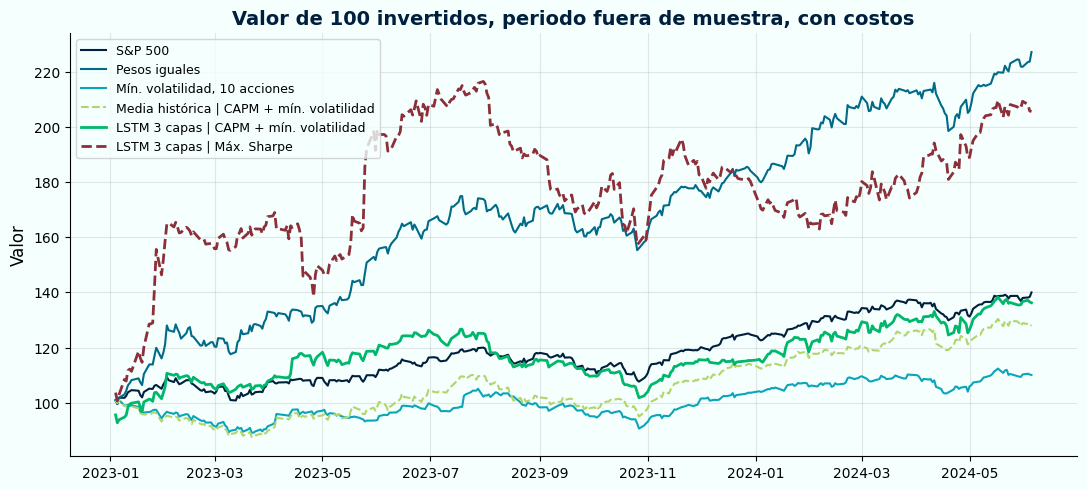

In [ ]:
mostrar = ['S&P 500', 'Pesos iguales', 'Mín. volatilidad, 10 acciones',
           f'Media histórica | CAPM + mín. volatilidad',
           f'{MODELO_PROYECTO} | CAPM + mín. volatilidad', f'{MODELO_PROYECTO} | Máx. Sharpe']
colores = [C_DARK, C_WRONG, C_TEAL, C_LIME, C_RIGHT, C_ERROR]
estilos = ['-', '-', '-', '--', '-', '--']
fig, ax = plt.subplots(figsize=(13, 5.5))
for nombre, c, ls in zip(mostrar, colores, estilos):
    v = (1 + ESTRATEGIAS[nombre][0]).cumprod() * 100
    ax.plot(v.index, v.values, color=c, linestyle=ls, linewidth=2 if nombre.startswith(MODELO_PROYECTO) else 1.5, label=nombre)
ax.set_title('Valor de 100 invertidos, periodo fuera de muestra, con costos')
ax.set_ylabel('Valor'); ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
plt.show()

### Resultado de las decisiones del portafolio

- **¿Filtrar con CAPM?** Con mínima volatilidad: `Mín. volatilidad, 10 acciones` contra `LSTM 3 capas | CAPM + mín. volatilidad`. Con máximo Sharpe: `LSTM 3 capas | Máx. Sharpe` contra `LSTM 3 capas | CAPM + máx. Sharpe`. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-capm_filtro)
- **¿Mínima volatilidad o máximo Sharpe?** Con el mismo modelo y el mismo filtro, más pesos iguales como referencia. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-markowitz_objetivo)

In [ ]:
cols = ['Rend. anual', 'Volatilidad anual', 'Sharpe', 'Caída máxima', 'P(Sharpe > pesos iguales)', 'Activos con peso']
fmt = {'Rend. anual': '{:.1%}', 'Volatilidad anual': '{:.1%}', 'Sharpe': '{:.2f}', 'Caída máxima': '{:.1%}',
       'P(Sharpe > pesos iguales)': '{:.0%}', 'Activos con peso': '{:.1f}'}
d3 = MET_PORT.loc[['Mín. volatilidad, 10 acciones', f'{MODELO_PROYECTO} | CAPM + mín. volatilidad',
                   f'{MODELO_PROYECTO} | Máx. Sharpe', f'{MODELO_PROYECTO} | CAPM + máx. Sharpe'], cols]
d4 = MET_PORT.loc[[f'{MODELO_PROYECTO} | CAPM + mín. volatilidad', f'{MODELO_PROYECTO} | CAPM + máx. Sharpe', 'Pesos iguales'], cols]
print("Decisión: ¿filtrar con CAPM?")
display(d3.style.format(fmt))
print("Decisión: ¿mínima volatilidad o máximo Sharpe?")
display(d4.style.format(fmt))

lp = pd.DataFrame(LOG_PORTAFOLIO)
capm = lp[lp['estrategia'].str.contains('CAPM')]
print(f"Fechas en que menos de {MIN_ACTIVOS} acciones pasaron el filtro y se tomaron las de mayor alfa: "
      f"{capm['forzado'].mean():.0%} de los casos")
print(f"Fechas en que ningún activo superaba la tasa y máx. Sharpe cayó a mín. volatilidad: "
      f"{lp[lp['estrategia'].str.contains('Sharpe')]['sharpe_indefinido'].mean():.0%} de los casos")

Decisión: ¿filtrar con CAPM?


,Rend. anual,Volatilidad anual,Sharpe,Caída máxima,P(Sharpe > pesos iguales),Activos con peso
Estrategia,,,,,,
"Mín. volatilidad, 10 acciones",7.0%,12.6%,0.19,-13.7%,0%,6.2
LSTM 3 capas | CAPM + mín. volatilidad,24.4%,18.2%,1.01,-19.6%,0%,3.3
LSTM 3 capas | Máx. Sharpe,66.3%,34.3%,1.50,-27.3%,2%,2.2
LSTM 3 capas | CAPM + máx. Sharpe,66.4%,34.3%,1.50,-27.4%,2%,2.2


Decisión: ¿mínima volatilidad o máximo Sharpe?


,Rend. anual,Volatilidad anual,Sharpe,Caída máxima,P(Sharpe > pesos iguales),Activos con peso
Estrategia,,,,,,
LSTM 3 capas | CAPM + mín. volatilidad,24.4%,18.2%,1.01,-19.6%,0%,3.3
LSTM 3 capas | CAPM + máx. Sharpe,66.4%,34.3%,1.50,-27.4%,2%,2.2
Pesos iguales,78.5%,20.2%,2.72,-11.2%,0%,10.0


Fechas en que menos de 3 acciones pasaron el filtro y se tomaron las de mayor alfa: 18% de los casos
Fechas en que ningún activo superaba la tasa y máx. Sharpe cayó a mín. volatilidad: 2% de los casos


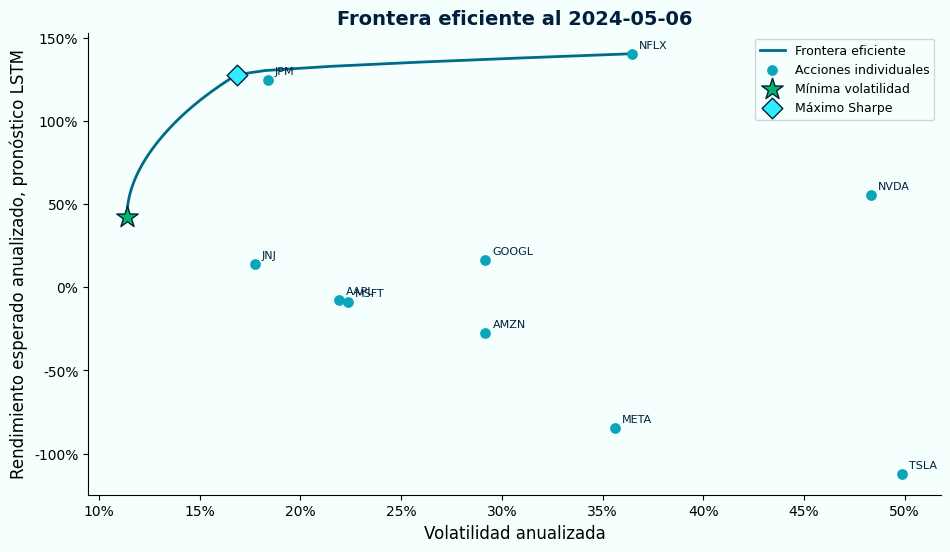

In [ ]:
# Frontera eficiente en la última fecha de decisión, en unidades anualizadas.
p_last = REBAL[-1]
mu_last = mu_de(MODELO_PROYECTO, p_last)
S_last = cov_en(p_last, SYMBOLS)
rf_last = rf_diaria.iloc[p_last] * H
esc_r, esc_v = 252 / H, np.sqrt(252 / H)

w_mv = min_vol(S_last)
w_ms, _ = max_sharpe(mu_last.values, S_last, rf_last)
r_min = w_mv @ mu_last.values
objetivos = np.linspace(r_min, mu_last.max(), 40)
frontera, w0 = [], w_mv.copy()
for t in objetivos:
    cons = ({'type': 'eq', 'fun': lambda w: w.sum() - 1}, {'type': 'eq', 'fun': lambda w, t=t: w @ mu_last.values - t})
    res = minimize(lambda w: w @ S_last @ w, w0, method='SLSQP', bounds=[(0, 1)] * 10, constraints=cons,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    if res.success:
        w0 = res.x                                  # arranque en caliente desde el punto anterior
        frontera.append((np.sqrt(res.x @ S_last @ res.x), t))
frontera = np.array(frontera)
if len(frontera):                                   # solo la rama eficiente: volatilidad no decreciente
    frontera = frontera[np.maximum.accumulate(frontera[:, 0]) <= frontera[:, 0] + 1e-9]

fig, ax = plt.subplots(figsize=(11, 6))
if len(frontera):
    ax.plot(frontera[:, 0] * esc_v, frontera[:, 1] * esc_r, color=C_WRONG, linewidth=2, label='Frontera eficiente')
vol_ind = np.sqrt(np.diag(S_last))
ax.scatter(vol_ind * esc_v, mu_last.values * esc_r, color=C_TEAL, s=45, zorder=4, label='Acciones individuales')
for s, x, yv in zip(SYMBOLS, vol_ind * esc_v, mu_last.values * esc_r):
    ax.annotate(s, (x, yv), textcoords='offset points', xytext=(5, 4), fontsize=8, color=C_DARK)
ax.scatter(np.sqrt(w_mv @ S_last @ w_mv) * esc_v, (w_mv @ mu_last.values) * esc_r, marker='*', s=260,
           color=C_RIGHT, edgecolor=C_DARK, zorder=5, label='Mínima volatilidad')
ax.scatter(np.sqrt(w_ms @ S_last @ w_ms) * esc_v, (w_ms @ mu_last.values) * esc_r, marker='D', s=110,
           color=C_ACCENT, edgecolor=C_DARK, zorder=5, label='Máximo Sharpe')
ax.set_xlabel('Volatilidad anualizada'); ax.set_ylabel('Rendimiento esperado anualizado, pronóstico LSTM')
ax.set_title(f'Frontera eficiente al {idx[p_last].date()}')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=9)
plt.show()

## 12. Exportación para el Explorador de decisiones

- Los resultados de cada alternativa se guardan en `explorador_resultados.json`, con las mismas etiquetas de opción que usa el Explorador del artículo.
- Así el sitio y el notebook salen de la misma fuente: si cambias algo aquí y vuelves a correr, el Explorador muestra los números nuevos.
- También se guardan las tablas completas en CSV.

In [ ]:
def _num(x, nd):
    x = float(x)
    return None if not np.isfinite(x) else round(x, nd)

def _pron(m):
    r = MET_PRON.loc[m]
    return {'r2_oos': _num(r['R² vs paseo aleatorio'], 4), 'ic': _num(r['IC medio'], 4),
            'acierto_direccion': _num(r['Acierto de dirección'], 4), 'mae': _num(r['MAE'], 4),
            'minutos_entrenamiento': _num(r['Minutos de entrenamiento'], 1)}

def _port(e):
    r = MET_PORT.loc[e]
    return {'sharpe': _num(r['Sharpe'], 3), 'sharpe_ic95': [_num(r['Sharpe IC 95% bajo'], 3), _num(r['Sharpe IC 95% alto'], 3)],
            'rend_anual': _num(r['Rend. anual'], 4), 'vol_anual': _num(r['Volatilidad anual'], 4),
            'caida_maxima': _num(r['Caída máxima'], 4), 'p_supera_pesos_iguales': _num(r['P(Sharpe > pesos iguales)'], 3),
            'activos_con_peso': _num(r['Activos con peso'], 1)}

EXPLORADOR = {
    'meta': {'ejecutado': datetime.now().strftime('%Y-%m-%d'), 'periodo_fuera_de_muestra':
             [str(idx[REBAL[0] + 1].date()), str(idx[REBAL[-1] + H].date())], 'fechas_decision': len(REBAL),
             'config': CONFIG},
    'lstm_indicadores': {'Solo precio de cierre': _pron('LSTM 3 capas, solo precio'),
                         'Con 4 indicadores técnicos': _pron('LSTM 3 capas')},
    'lstm_arquitectura': {'Una sola capa (50 unidades)': _pron('LSTM 1 capa'),
                          'Tres capas apiladas + Dropout': _pron('LSTM 3 capas'),
                          'GRU de tres capas': _pron('GRU 3 capas'),
                          'Ridge con la misma ventana': _pron('Ridge')},
    'capm_filtro': {'Incluir todos los activos': _port('Mín. volatilidad, 10 acciones'),
                    'Filtrar primero con CAPM': _port(f'{MODELO_PROYECTO} | CAPM + mín. volatilidad')},
    'markowitz_objetivo': {'Mínima volatilidad': _port(f'{MODELO_PROYECTO} | CAPM + mín. volatilidad'),
                           'Máximo ratio de Sharpe': _port(f'{MODELO_PROYECTO} | CAPM + máx. Sharpe'),
                           'Pesos iguales (referencia)': _port('Pesos iguales')},
    'modelos_vs_baselines': {m: _pron(m) for m in MET_PRON.index},
}
with open('explorador_resultados.json', 'w', encoding='utf-8') as fh:
    json.dump(EXPLORADOR, fh, ensure_ascii=False, indent=2, allow_nan=False)
MET_PRON.to_csv('metricas_pronostico.csv')
MET_PORT.to_csv('metricas_portafolio.csv')
print(json.dumps({k: v for k, v in EXPLORADOR.items() if k != 'meta'}, ensure_ascii=False, indent=1)[:1500], '...')

{
 "lstm_indicadores": {
  "Solo precio de cierre": {
   "r2_oos": 0.155,
   "ic": 0.0766,
   "acierto_direccion": 0.5529,
   "mae": 0.0809,
   "minutos_entrenamiento": 9.6
  },
  "Con 4 indicadores técnicos": {
   "r2_oos": -0.0459,
   "ic": -0.0096,
   "acierto_direccion": 0.5529,
   "mae": 0.0881,
   "minutos_entrenamiento": 7.4
  }
 },
 "lstm_arquitectura": {
  "Una sola capa (50 unidades)": {
   "r2_oos": 0.052,
   "ic": 0.0339,
   "acierto_direccion": 0.5412,
   "mae": 0.0853,
   "minutos_entrenamiento": 4.5
  },
  "Tres capas apiladas + Dropout": {
   "r2_oos": -0.0459,
   "ic": -0.0096,
   "acierto_direccion": 0.5529,
   "mae": 0.0881,
   "minutos_entrenamiento": 7.4
  },
  "GRU de tres capas": {
   "r2_oos": 0.0276,
   "ic": -0.0004,
   "acierto_direccion": 0.5412,
   "mae": 0.0881,
   "minutos_entrenamiento": 8.1
  },
  "Ridge con la misma ventana": {
   "r2_oos": 0.0134,
   "ic": 0.0724,
   "acierto_direccion": 0.5588,
   "mae": 0.0839,
   "minutos_entrenamiento": 0.0
  }
 }

## Checklist metodológico

Cada punto se verifica con código en la celda siguiente. Si alguno falla, la celda se detiene con un error en vez de dejar pasar un resultado contaminado.

- **Sin fuga en el escalado.** Cada scaler se ajustó con filas que terminan antes del inicio de la validación y antes de T, y sus medias coinciden con las de esas filas.
- **Purga del objetivo.** Ningún objetivo usado en entrenamiento termina después de T.
- **Embargo.** Ningún objetivo del ajuste se traslapa con el periodo de validación.
- **Pronóstico hacia adelante.** Todo pronóstico se hizo en una fecha igual o posterior al reentrenamiento que lo produjo.
- **Indicadores sin mirar el futuro.** Recalcular los indicadores con la serie recortada en T da exactamente el mismo valor en T que calcularlos sobre la serie completa.
- **El objetivo es lo que dice ser.** El valor del objetivo coincide con el rendimiento logarítmico a 21 días recalculado desde los precios.
- **CAPM y covarianza con datos hasta T.** Toda beta termina en T y todo periodo de tenencia empieza después de T.
- **Pesos válidos.** Todos suman 1 y ninguno es negativo.
- **Cobertura completa.** Cada modelo tiene un pronóstico por acción y por fecha de decisión.

In [ ]:
le = pd.DataFrame(LOG_ENTRENAMIENTO)
lp = pd.DataFrame(LOG_PORTAFOLIO)
rng = np.random.default_rng(SEED)

assert (le['fin_scaler'] < le['inicio_val']).all() and (le['fin_scaler'] <= le['p_T']).all(), "Scaler ajustado con datos de validación o posteriores a T"
assert (le['fin_objetivo_train'] <= le['p_T']).all(), "Un objetivo de entrenamiento termina después de T"
assert (le['fin_fit_mas_H'] < le['inicio_val']).all(), "El ajuste y la validación se traslapan"
assert (le['min_pred_pos'] >= le['p_T']).all(), "Se pronosticó antes del entrenamiento que produjo el pronóstico"

for _ in range(15):
    s = rng.choice(SYMBOLS); p = int(rng.choice(REBAL))
    completo = FEATURES[s].iloc[p]
    recortado = calcular_features(precios[s].iloc[:p + 1]).iloc[-1]
    assert np.allclose(completo.values, recortado.values, equal_nan=True), f"Indicador de {s} mira el futuro en {idx[p].date()}"

for _ in range(15):
    s = rng.choice(SYMBOLS); p = int(rng.choice(REBAL))
    assert np.isclose(OBJETIVO[s].iloc[p], np.log(precios[s].iloc[p + H] / precios[s].iloc[p])), "El objetivo no es el rendimiento a 21 días"

con_beta = lp.dropna(subset=['fin_beta'])
assert all(fb == idx[p] for fb, p in zip(con_beta['fin_beta'], con_beta['p'])), "Una beta usa datos posteriores a T"
assert all(it > idx[p] for it, p in zip(lp['inicio_tenencia'], lp['p'])), "Un periodo de tenencia empieza antes de T"
assert all(abs(sum(w.values()) - 1) < 1e-3 and min(w.values()) >= 0 for w in lp['pesos']), "Pesos inválidos"

cobertura = PRONOSTICOS.groupby('modelo').size()
assert (cobertura == len(REBAL) * len(SYMBOLS)).all(), "Falta algún pronóstico"

print("Checklist metodológico verificado:")
print(f"- {len(le)} entrenamientos auditados: escalado, purga, embargo y orden temporal correctos")
print(f"- 15 recálculos de indicadores sobre series recortadas coinciden con la serie completa")
print(f"- 15 objetivos recalculados desde precios coinciden")
print(f"- {len(lp)} portafolios auditados: beta hasta T, tenencia después de T, pesos válidos")
print(f"- {len(cobertura)} modelos con {len(REBAL)} × {len(SYMBOLS)} pronósticos cada uno")

Checklist metodológico verificado:
- 360 entrenamientos auditados: escalado, purga, embargo y orden temporal correctos
- 15 recálculos de indicadores sobre series recortadas coinciden con la serie completa
- 15 objetivos recalculados desde precios coinciden
- 391 portafolios auditados: beta hasta T, tenencia después de T, pesos válidos
- 8 modelos con 17 × 10 pronósticos cada uno


## Resumen automático de resultados

Esta celda redacta los hallazgos con los números de esta corrida, para que la conclusión nunca se escriba antes de ver el resultado.

In [ ]:
r2 = MET_PRON['R² vs paseo aleatorio']
ml = list(MODELOS)
mejor = r2[ml].idxmax()
hm = r2['Media histórica']
sh = MET_PORT['Sharpe']
pipe = f'{MODELO_PROYECTO} | CAPM + mín. volatilidad'

print(f"• Mejor modelo por R² fuera de muestra: {mejor} ({r2[mejor]:+.3f}); media histórica: {hm:+.3f}.")
print(f"• Modelos que superan al paseo aleatorio: {', '.join(r2[ml][r2[ml] > 0].index) or 'ninguno'}.")
print(f"• Modelos que superan a la media histórica: {', '.join(r2[ml][r2[ml] > hm].index) or 'ninguno'}.")
print(f"• IC del modelo del proyecto: {MET_PRON.loc[MODELO_PROYECTO, 'IC medio']:+.3f} (t = {MET_PRON.loc[MODELO_PROYECTO, 'IC t-stat']:+.2f}).")
print(f"• Indicadores vs solo precio en LSTM 3 capas: R² {r2['LSTM 3 capas']:+.3f} vs {r2['LSTM 3 capas, solo precio']:+.3f}.")
print(f"• Profundidad y celda: LSTM 1 capa {r2['LSTM 1 capa']:+.3f}, LSTM 3 capas {r2['LSTM 3 capas']:+.3f}, GRU 3 capas {r2['GRU 3 capas']:+.3f}, Ridge {r2['Ridge']:+.3f}.")
print(f"• Pipeline del proyecto, Sharpe {sh[pipe]:.2f} (IC 95% {MET_PORT.loc[pipe, 'Sharpe IC 95% bajo']:.2f} a {MET_PORT.loc[pipe, 'Sharpe IC 95% alto']:.2f}); "
      f"pesos iguales {sh['Pesos iguales']:.2f}; S&P 500 {sh['S&P 500']:.2f}; mín. volatilidad sin filtro {sh['Mín. volatilidad, 10 acciones']:.2f}.")
print(f"• Máximo Sharpe con el mismo modelo y filtro: {sh[f'{MODELO_PROYECTO} | CAPM + máx. Sharpe']:.2f}.")
top = sh.drop(['S&P 500']).idxmax()
print(f"• Estrategia con mayor Sharpe: {top} ({sh[top]:.2f}), P(> pesos iguales) = {MET_PORT.loc[top, 'P(Sharpe > pesos iguales)']:.0%}.")

• Mejor modelo por R² fuera de muestra: LSTM 3 capas, solo precio (+0.155); media histórica: -0.098.
• Modelos que superan al paseo aleatorio: Ridge, Gradient Boosting, LSTM 1 capa, GRU 3 capas, LSTM 3 capas, solo precio.
• Modelos que superan a la media histórica: Ridge, Gradient Boosting, LSTM 1 capa, LSTM 3 capas, GRU 3 capas, LSTM 3 capas, solo precio.
• IC del modelo del proyecto: -0.010 (t = -0.11).
• Indicadores vs solo precio en LSTM 3 capas: R² -0.046 vs +0.155.
• Profundidad y celda: LSTM 1 capa +0.052, LSTM 3 capas -0.046, GRU 3 capas +0.028, Ridge +0.013.
• Pipeline del proyecto, Sharpe 1.01 (IC 95% -0.55 a 2.55); pesos iguales 2.72; S&P 500 1.55; mín. volatilidad sin filtro 0.19.
• Máximo Sharpe con el mismo modelo y filtro: 1.50.
• Estrategia con mayor Sharpe: Pesos iguales (2.72), P(> pesos iguales) = 0%.


## Hallazgos y siguientes pasos

Los números concretos de esta corrida están en el resumen automático de arriba. Lo que el diseño del experimento deja claro, sin importar qué modelo gane:

- **Un modelo solo vale lo que gana contra la alternativa simple.** La media histórica y el paseo aleatorio son la vara. Sin ellos, cualquier MSE bajo parece un logro.
- **El pronóstico tiene que llegar a los pesos.** Mínima volatilidad sobre todo el universo ignora el pronóstico por completo. El modelo solo influye a través del filtro CAPM o de un objetivo que use rendimientos, como el máximo Sharpe.
- **La evaluación que importa es la del portafolio, fuera de muestra y con costos.** Un buen R² que no mejora el Sharpe no le sirve a quien invierte, y un Sharpe mejor que no sale del intervalo de confianza todavía no es una conclusión.
- **Pronosticar rendimientos y no precios** evita el problema de extrapolar fuera del rango de entrenamiento que tenía la primera versión.

Si quieres ir más allá:

- Revisa las 4 decisiones exploradas en este notebook, con su alternativa y el resultado que hubieras obtenido, en el [artículo completo](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/).
- Lee la sección "Cómo adaptarlo" del artículo para ver qué cambiaría con tu propio universo de activos, tu propio proxy de mercado o tu propio objetivo de optimización.
- El repositorio en GitHub tiene el diagrama editable del pipeline y el README con las referencias académicas de cada decisión.

<br>

## Siguientes pasos: de caso de estudio a proyecto publicable o listo para producción

Este notebook demuestra el criterio correcto: evaluar sin fugas, contra alternativas simples y fuera de muestra. Sus resultados describen este caso, pero todavía no alcanzan para generalizarlos. Para llevarlo a una revista académica de nivel Q2 o a un sistema que opere dinero real, estos son los cuatro frentes a fortalecer.

**1. Universo**
- Usar los constituyentes históricos del S&P 500 en cada fecha de decisión, no las acciones que hoy sabemos que sobrevivieron y ganaron.
- Así se elimina el sesgo de supervivencia y de selección, que en este notebook infla el desempeño de cualquier estrategia, empezando por pesos iguales.

**2. Periodo**
- Extender la evaluación fuera de muestra a por lo menos 10 o 15 años, por ejemplo de 2010 a 2024.
- Incluir varios regímenes de mercado: alcistas, bajistas, alta inflación y crisis. Un resultado que solo se sostiene en un mercado alcista no es un resultado.

**3. Robustez**
- Entrenar cada red con varias semillas y reportar el promedio y la dispersión, no una sola corrida.
- Comparar pronósticos con la prueba de Diebold-Mariano y diferencias de Sharpe con la prueba de Ledoit y Wolf.
- Corregir por comparaciones múltiples con el Deflated Sharpe Ratio: con decenas de estrategias, alguna gana por azar.
- Medir la sensibilidad a los costos de transacción, al horizonte de rebalanceo y a los hiperparámetros.
- Para producción: monitorear la deriva de los datos, reentrenar con un calendario fijo y definir con anticipación qué resultado haría retirar el modelo.

**4. Encuadre**
- Presentar el trabajo como una replicación crítica: muchos artículos que combinan LSTM y Markowitz reportan resultados inflados por fugas como las que este notebook corrige.
- Si el resultado se mantiene con un universo y un periodo amplios, que un modelo de Machine Learning no supere a la estrategia de pesos iguales es en sí mismo una contribución, en línea con DeMiguel, Garlappi y Uppal (2009).

---
<br>

Made with 💚 by FuzzyFrog.AI

# Optimización de carteras con LSTM, CAPM y Markowitz

Este notebook acompaña al artículo [Optimización de carteras con Machine Learning: LSTM, CAPM y Markowitz](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/) de FuzzyFrog.AI. Usa datos abiertos de Yahoo Finance, así que no depende de ningún archivo de datos externo, todo se descarga en vivo dentro del propio notebook.

A diferencia de un tutorial que corre una sola vez y enseña un solo número, aquí cada decisión del pipeline se pone a prueba contra sus alternativas, con un backtest fuera de muestra, y los resultados alimentan el Explorador de decisiones del artículo.

**Ejecutado y probado de principio a fin el 25 de septiembre de 2026.**

Las librerías, APIs y el entorno de Google Colab pueden cambiar con el tiempo, así que es posible que en el futuro algo de este notebook deje de funcionar tal cual. Eso no significa que el enfoque esté mal, significa que algo cambió después de esta fecha. Si te falla una celda o encuentras un error, escríbenos para que lo revisemos.

Recomendado: en Colab, activa un entorno con GPU en *Entorno de ejecución → Cambiar tipo de entorno de ejecución*. El backtest entrena varios cientos de modelos pequeños y con GPU tarda alrededor de media hora.

## Qué vas a aprender

Vas a practicar el criterio más importante de un proyecto cuantitativo: **no confiar en un modelo hasta compararlo, fuera de muestra, contra la alternativa más simple que existe**. En el camino tocas validación walk-forward con purga, CAPM como filtro por alfa, y por qué el objetivo del optimizador decide si tu pronóstico sirve o no.

## 0. Configuración y reproducibilidad

- Todas las decisiones numéricas del experimento viven en esta celda, para que cambiarlas no requiera buscar en el resto del notebook.
- Se fija una semilla global y se activa el determinismo de TensorFlow, así dos corridas del mismo notebook dan los mismos números.
- Se imprimen las versiones de cada librería, porque un resultado sin su entorno no se puede reproducir.

In [ ]:
import os, time, json, pickle, hashlib, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import yfinance as yf
import scipy
from scipy.optimize import minimize
from scipy.stats import spearmanr
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.covariance import LedoitWolf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore", category=FutureWarning)
tf.get_logger().setLevel("ERROR")   # silencia avisos de retracing al predecir en bucle

# ── Universo y fechas ──
SYMBOLS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'JPM', 'JNJ']
FECHA_INICIAL   = "2020-01-01"
FECHA_FINAL     = "2024-07-01"
INICIO_BACKTEST = "2023-01-01"   # desde aquí todo es fuera de muestra

# ── Diseño del experimento ──
H              = 21     # horizonte y periodo de tenencia: 21 días hábiles, aprox. un mes
WINDOW         = 20     # días de historia que ve cada modelo por predicción
LOOKBACK_COV   = 252    # un año de rendimientos diarios para covarianza
LOOKBACK_BETA  = 252    # un año de rendimientos diarios para beta
RETRAIN_EVERY  = 3      # los modelos se reentrenan cada 3 rebalanceos, aprox. trimestral
VAL_FRAC       = 0.2    # fracción final del entrenamiento usada como validación interna
EPOCHS_MAX     = 60
PATIENCE       = 8
BATCH_SIZE     = 32
COSTO_TRANSACCION = 0.001   # 10 puntos base por unidad de rotación del portafolio
MIN_ACTIVOS    = 3          # mínimo de activos que deben entrar al optimizador
N_BOOTSTRAP    = 2000
SEED           = 42

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Aviso: no se pudo activar el determinismo de TensorFlow:", e)

print("Ejecutado:", datetime.now().strftime("%Y-%m-%d %H:%M"))
for lib in [np, pd, scipy, sklearn, tf, yf]:
    print(f"{lib.__name__:12s} {lib.__version__}")
print("GPU disponible:", bool(tf.config.list_physical_devices('GPU')))

# ── Paleta FuzzyFrog ──
C_WRONG  = "#006a87"
C_RIGHT  = "#00b76c"
C_ACCENT = "#32ecfd"
C_DARK   = "#001f3d"
C_LIGHT  = "#f4fffe"
C_LIME   = "#b2d56a"
C_TEAL   = "#0aa5b8"
C_ERROR  = "#8c2f39"

plt.rcParams.update({
    "figure.facecolor":  C_LIGHT,
    "axes.facecolor":    C_LIGHT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "axes.titlecolor":   C_DARK,
    "axes.titleweight":  "bold",
})
_brand_cmap = LinearSegmentedColormap.from_list("fuzzyfrog", [C_WRONG, C_ACCENT, C_RIGHT, C_DARK])
_brand_div  = LinearSegmentedColormap.from_list("fuzzyfrog_div", [C_ERROR, C_LIGHT, C_RIGHT])

def brand_colors(n):
    """Genera n colores distinguibles dentro de la paleta de marca FuzzyFrog.AI."""
    return [_brand_cmap(i / max(n - 1, 1)) for i in range(n)]

Ejecutado: 2026-09-25 16:18
numpy        2.1.3
pandas       2.2.3
scipy        1.16.3
sklearn      1.6.1
tensorflow   2.20.0
yfinance     0.2.66
GPU disponible: True


## Diagrama del pipeline

- Cada mes se toma una fecha de decisión T y **todo lo que está a la izquierda de T es lo único que el pipeline puede ver**.
- Los modelos pronostican el rendimiento del mes siguiente, CAPM filtra por alfa, Markowitz reparte el dinero y el portafolio se mide en el mes que todavía no había pasado.
- Después T avanza un mes y el ciclo se repite. Eso es un backtest walk-forward.

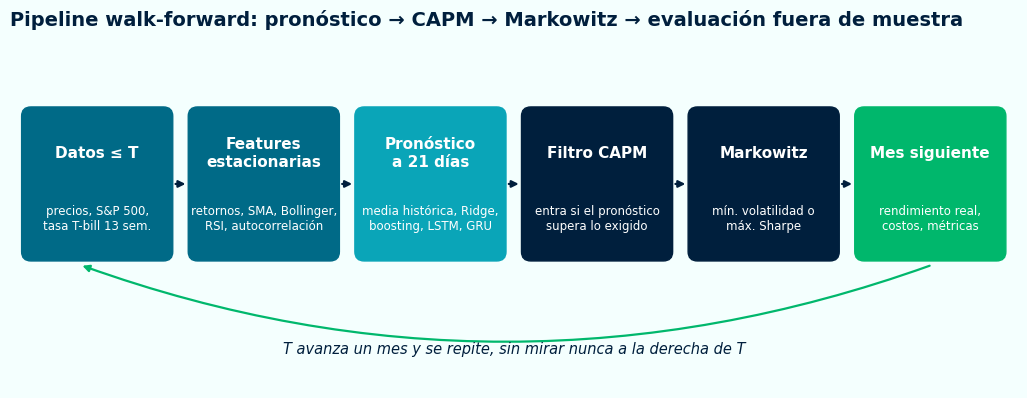

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.6); ax.axis('off')

cajas = [
    (0.2,  "Datos ≤ T",            "precios, S&P 500,\ntasa T-bill 13 sem.", C_WRONG),
    (2.35, "Features\nestacionarias", "retornos, SMA, Bollinger,\nRSI, autocorrelación", C_WRONG),
    (4.5,  "Pronóstico\na 21 días", "media histórica, Ridge,\nboosting, LSTM, GRU", C_TEAL),
    (6.65, "Filtro CAPM",          "entra si el pronóstico\nsupera lo exigido", C_DARK),
    (8.8,  "Markowitz",            "mín. volatilidad o\nmáx. Sharpe", C_DARK),
    (10.95,"Mes siguiente",        "rendimiento real,\ncostos, métricas", C_RIGHT),
]
for x, titulo, sub, color in cajas:
    ax.add_patch(FancyBboxPatch((x, 1.7), 1.85, 1.9, boxstyle="round,pad=0.05,rounding_size=0.12",
                                facecolor=color, edgecolor=color))
    ax.text(x + 0.925, 3.05, titulo, ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    ax.text(x + 0.925, 2.2, sub, ha='center', va='center', color='white', fontsize=8.5)
for i in range(len(cajas) - 1):
    x0 = cajas[i][0] + 1.9; x1 = cajas[i + 1][0] - 0.05
    ax.annotate("", xy=(x1, 2.65), xytext=(x0, 2.65),
                arrowprops=dict(arrowstyle="-|>", color=C_DARK, lw=1.6))
ax.annotate("", xy=(0.9, 1.6), xytext=(11.9, 1.6),
            arrowprops=dict(arrowstyle="-|>", color=C_RIGHT, lw=1.6, connectionstyle="arc3,rad=-0.18"))
ax.text(6.5, 0.45, "T avanza un mes y se repite, sin mirar nunca a la derecha de T",
        ha='center', color=C_DARK, fontsize=10.5, style='italic')
ax.set_title("Pipeline walk-forward: pronóstico → CAPM → Markowitz → evaluación fuera de muestra", loc='left')
plt.show()

## 1. Obtención de los datos: precios de activos

Datos abiertos de Yahoo Finance para diez acciones de alta capitalización:

- AAPL (Apple Inc.)
- MSFT (Microsoft Corporation)
- GOOGL (Alphabet Inc., Clase A)
- AMZN (Amazon.com Inc.)
- TSLA (Tesla, Inc.)
- META (Meta Platforms, Inc.)
- NFLX (Netflix, Inc.)
- NVDA (NVIDIA Corporation)
- JPM (JPMorgan Chase & Co.)
- JNJ (Johnson & Johnson)

Además se descargan dos series que el pipeline necesita para no inventar supuestos:

- **S&P 500 (^GSPC)** como proxy del mercado para calcular beta.
- **Tasa del T-bill a 13 semanas (^IRX)** como tasa libre de riesgo del periodo, en lugar de un 2% fijo que en 2023 y 2024 habría quedado muy por debajo de la tasa real del mercado.

Se recupera el histórico entre el 1 de enero de 2020 y el 1 de julio de 2024. Este rango queda fijo para que el notebook sea reproducible, si quieres datos más recientes solo cambia `FECHA_FINAL`.

In [ ]:
def descargar_cierres(tickers, start, end):
    """Descarga precios de cierre ajustados. auto_adjust=True hace que 'Close'
    ya incorpore dividendos y splits, que es el valor por defecto actual de
    yfinance; se declara explícito para que no dependa de la versión."""
    df = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    close = df['Close']
    if isinstance(close, pd.Series):
        close = close.to_frame(tickers if isinstance(tickers, str) else tickers[0])
    return close

precios_raw = descargar_cierres(SYMBOLS, FECHA_INICIAL, FECHA_FINAL)[SYMBOLS]
sp500_raw   = descargar_cierres('^GSPC', FECHA_INICIAL, FECHA_FINAL).iloc[:, 0]
irx_raw     = descargar_cierres('^IRX',  FECHA_INICIAL, FECHA_FINAL).iloc[:, 0]

# Calendario común: solo días en que cotizan las 10 acciones y el índice.
# La tasa se rellena hacia adelante porque el mercado de bonos cierra en
# algunos feriados en que la bolsa sí abre; nunca se rellena hacia atrás.
idx = precios_raw.dropna().index.intersection(sp500_raw.dropna().index)
precios = precios_raw.loc[idx]
sp500   = sp500_raw.loc[idx].rename('SP500')
irx     = irx_raw.reindex(idx).ffill()

assert precios.notna().all().all(), "Hay precios faltantes en el calendario común"
assert irx.notna().all(), "La tasa libre de riesgo tiene huecos al inicio de la serie"

rf_diaria = (irx / 100.0) / 252          # tasa anual en % convertida a rendimiento diario
ret_simple = precios.pct_change()         # rendimientos simples diarios, para portafolio y CAPM
ret_mkt    = sp500.pct_change()
logp       = np.log(precios)

print(f"Periodo: {idx[0].date()} → {idx[-1].date()}  |  {len(idx)} días hábiles  |  {precios.shape[1]} acciones")
precios.tail(3)

Periodo: 2020-01-02 → 2024-06-28  |  1130 días hábiles  |  10 acciones


Ticker,AAPL,MSFT,GOOGL,AMZN,TSLA,META,NFLX,NVDA,JPM,JNJ
Date,,,,,,,,,,
2024-06-26,211.236404,444.327484,182.355820,193.610001,196.369995,509.296539,67.768997,126.050972,188.425156,138.040359
2024-06-27,212.078400,445.005493,183.873123,197.850006,197.419998,515.688538,68.433998,123.647614,190.085770,137.081375
2024-06-28,208.631256,439.207733,180.640106,193.250000,197.880005,500.462860,67.487999,123.198868,193.034836,137.419830


## 2. Explicación de los datos

- **Precio de cierre ajustado.** El precio de cierre es el último precio al que se negoció la acción en la sesión. El ajustado además incorpora dividendos y splits, así un salto por split no se confunde con un movimiento real.
- **Rendimiento diario.** Cambio porcentual del precio de un día al siguiente. Es la unidad con la que trabajan CAPM y Markowitz.
- **Rendimiento logarítmico a 21 días.** Es lo que se va a pronosticar: cuánto sube o baja la acción en el mes siguiente a la fecha de decisión.
- **Tasa libre de riesgo.** Rendimiento anual del T-bill a 13 semanas. Se convierte a diario para restarla y obtener rendimientos en exceso.

La tabla de abajo resume cada acción en el periodo previo al backtest, que es lo único que un analista habría conocido el 1 de enero de 2023.

In [ ]:
pre = ret_simple.loc[:INICIO_BACKTEST].dropna()
resumen = pd.DataFrame({
    'Rend. anual medio': pre.mean() * 252,
    'Volatilidad anual': pre.std() * np.sqrt(252),
    'Peor día': pre.min(),
    'Mejor día': pre.max(),
    'Autocorr. lag 1': pre.apply(lambda s: s.autocorr(1)),
})
print(f"Tasa T-bill: mín {irx.min():.2f}%, máx {irx.max():.2f}%, al inicio del backtest {irx.loc[:INICIO_BACKTEST].iloc[-1]:.2f}%")
resumen.style.format({'Rend. anual medio': '{:.1%}', 'Volatilidad anual': '{:.1%}',
                      'Peor día': '{:.1%}', 'Mejor día': '{:.1%}', 'Autocorr. lag 1': '{:.3f}'})

Tasa T-bill: mín -0.10%, máx 5.35%, al inicio del backtest 4.26%


,Rend. anual medio,Volatilidad anual,Peor día,Mejor día,Autocorr. lag 1
Ticker,,,,,
AAPL,25.8%,36.9%,-12.9%,12.0%,-0.151
MSFT,20.4%,34.8%,-14.7%,14.2%,-0.230
GOOGL,14.4%,34.5%,-11.6%,9.2%,-0.148
AMZN,3.6%,39.1%,-14.0%,13.5%,-0.031
TSLA,74.7%,72.2%,-21.1%,19.9%,-0.008
META,-6.3%,48.7%,-26.4%,17.6%,-0.067
NFLX,10.4%,51.9%,-35.1%,16.9%,-0.062
NVDA,45.5%,56.0%,-18.5%,17.2%,-0.127
JPM,8.5%,37.9%,-15.0%,18.0%,-0.150


## 3. Análisis exploratorio

Tres gráficas, cada una responde una pregunta que después condiciona una decisión.

- **¿Cómo se comparan los activos entre sí?** Precios en base 100 para ponerlos en la misma escala.
- **¿Hay diversificación posible?** La matriz de correlación es el insumo central de Markowitz. Correlaciones bajas significan que combinar activos reduce el riesgo.
- **¿Hay algo que pronosticar?** Si la autocorrelación de los rendimientos diarios es casi cero, ningún modelo va a sacar mucha señal del precio pasado, y la vara con la que se mide cualquier modelo tiene que ser una alternativa simple.

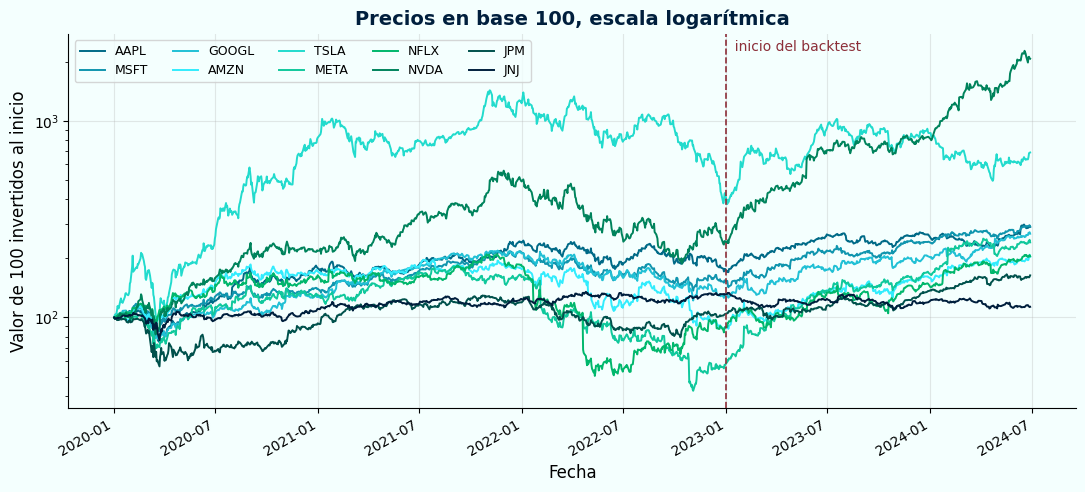

In [ ]:
base100 = precios / precios.iloc[0] * 100
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_prop_cycle(color=brand_colors(len(SYMBOLS)))
base100.plot(ax=ax, linewidth=1.4)
ax.axvline(pd.Timestamp(INICIO_BACKTEST), color=C_ERROR, linestyle='--', linewidth=1.2)
ax.text(pd.Timestamp(INICIO_BACKTEST), ax.get_ylim()[1] * 0.95, '  inicio del backtest', color=C_ERROR, fontsize=10)
ax.set_yscale('log')
ax.set_title('Precios en base 100, escala logarítmica')
ax.set_xlabel('Fecha'); ax.set_ylabel('Valor de 100 invertidos al inicio')
ax.legend(ncol=5, fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

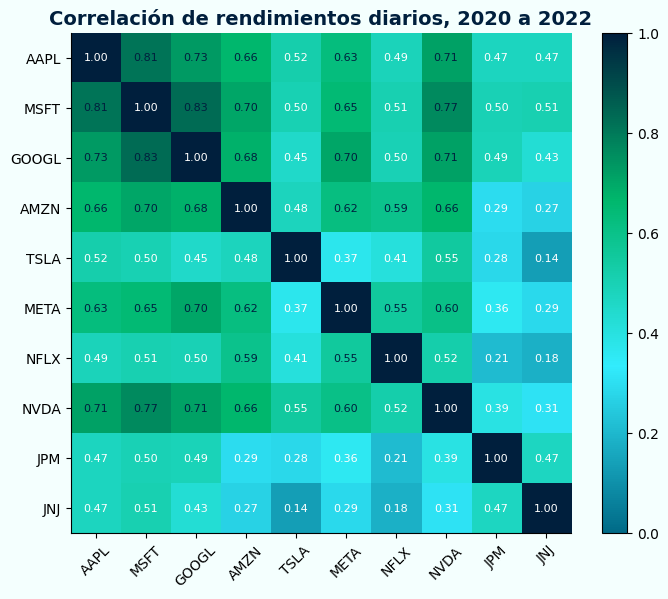

In [ ]:
corr = pre.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.values, cmap=_brand_cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(SYMBOLS))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(SYMBOLS))); ax.set_yticklabels(corr.columns)
for i in range(len(SYMBOLS)):
    for j in range(len(SYMBOLS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center', fontsize=8,
                color='white' if corr.values[i, j] < 0.55 or corr.values[i, j] > 0.9 else C_DARK)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlación de rendimientos diarios, 2020 a 2022')
plt.show()

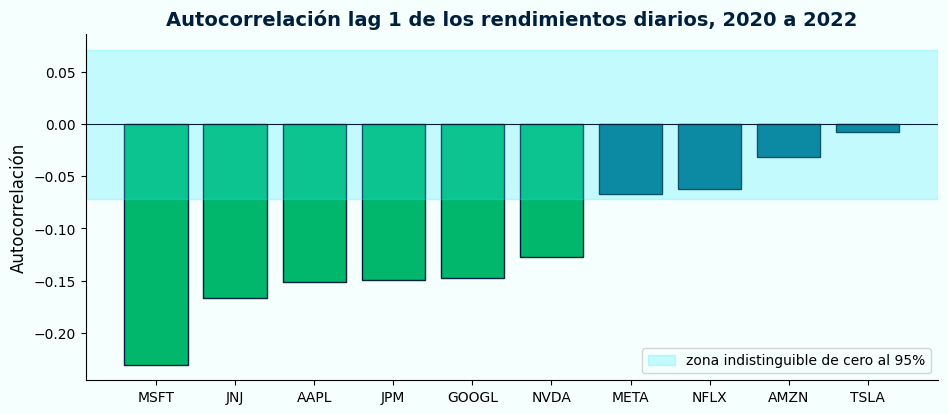

In [ ]:
n_obs = len(pre)
banda = 1.96 / np.sqrt(n_obs)
ac = resumen['Autocorr. lag 1'].sort_values()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(ac.index, ac.values, color=[C_RIGHT if abs(v) > banda else C_WRONG for v in ac.values], edgecolor=C_DARK)
ax.axhspan(-banda, banda, color=C_ACCENT, alpha=0.25, label='zona indistinguible de cero al 95%')
ax.axhline(0, color=C_DARK, linewidth=0.8)
ax.set_title('Autocorrelación lag 1 de los rendimientos diarios, 2020 a 2022')
ax.set_ylabel('Autocorrelación')
ax.legend()
plt.show()

Lo que dice la última gráfica marca todo lo que sigue: la memoria de corto plazo de los rendimientos es débil y, en varias acciones, indistinguible de cero. Por eso cada modelo de este notebook se compara contra dos alternativas que no aprenden nada, **la media histórica**, que es el insumo clásico de Markowitz, y **el paseo aleatorio**, que pronostica rendimiento cero. Si un modelo no les gana a esas dos, su complejidad no se justifica.

## 4. Lo que cambió respecto a la primera versión de este pipeline

La primera versión de este notebook pronosticaba **el nivel del precio** y calculaba el rendimiento esperado con las predicciones de los mismos 30 días de prueba. Tenía dos problemas que no se veían en las métricas, y se dejan documentados porque son el tipo de error que más se repite en proyectos de este tipo.

- **Precios fuera de rango.** El escalado MinMax se ajusta con el entrenamiento. Cuando el precio de prueba supera el máximo histórico, la red no sabe extrapolar y su predicción se queda plana. En NVDA la predicción quedó en unos 88 dólares mientras el precio real subía de 94 a 135. La gráfica de abajo muestra por qué.
- **Información del futuro en el rendimiento esperado.** Cada predicción de un día usaba los precios reales de los días anteriores del mismo periodo de prueba, así que el "rendimiento esperado" del mes ya contenía casi todo el mes. Ese número no lo habría tenido nadie el día que tenía que invertir.

La corrección es la base de esta versión: se pronostica el **rendimiento a 21 días**, que no tiene tendencia y se mantiene en rango, y se pronostica **desde la fecha de decisión hacia adelante**, con datos que solo llegan hasta ese día.

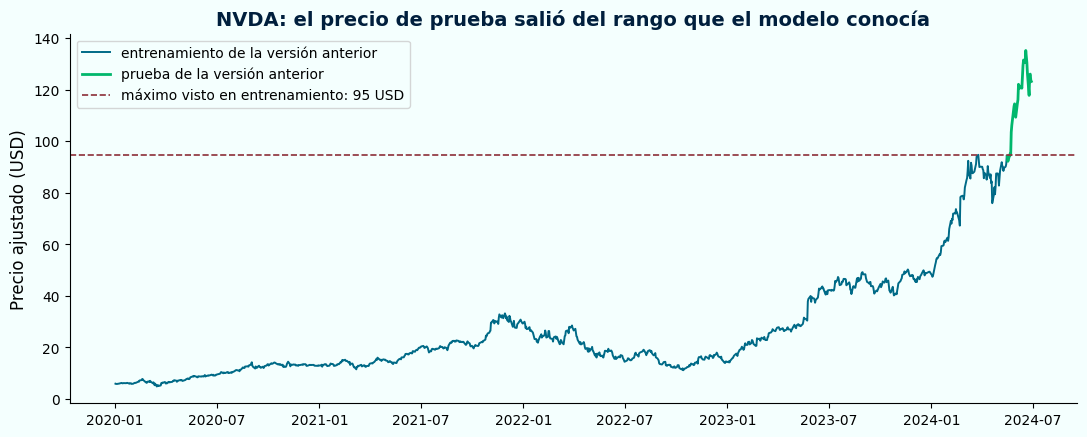

Rango del rendimiento diario de NVDA, entrenamiento: -0.204 a 0.218
Rango del rendimiento diario de NVDA, prueba:        -0.069 a 0.089


In [ ]:
nvda = precios['NVDA']
corte = len(nvda) - 30
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(nvda.index[:corte], nvda.values[:corte], color=C_WRONG, linewidth=1.4, label='entrenamiento de la versión anterior')
ax.plot(nvda.index[corte:], nvda.values[corte:], color=C_RIGHT, linewidth=2, label='prueba de la versión anterior')
ax.axhline(nvda.values[:corte].max(), color=C_ERROR, linestyle='--', linewidth=1.2,
           label=f'máximo visto en entrenamiento: {nvda.values[:corte].max():.0f} USD')
ax.set_title('NVDA: el precio de prueba salió del rango que el modelo conocía')
ax.set_ylabel('Precio ajustado (USD)')
ax.legend(loc='upper left')
plt.show()

lr_nvda = logp['NVDA'].diff()
print(f"Rango del rendimiento diario de NVDA, entrenamiento: {lr_nvda.iloc[:corte].min():.3f} a {lr_nvda.iloc[:corte].max():.3f}")
print(f"Rango del rendimiento diario de NVDA, prueba:        {lr_nvda.iloc[corte:].min():.3f} a {lr_nvda.iloc[corte:].max():.3f}")

## 5. Diseño de la evaluación: walk-forward con purga

- **Fechas de decisión.** Desde enero de 2023, una cada 21 días hábiles. En cada una se pronostica, se filtra, se optimiza y se invierte por los 21 días siguientes.
- **Purga.** El objetivo de un día es el rendimiento de los 21 días siguientes. Una muestra solo entra al entrenamiento si esos 21 días ya terminaron antes de T. Sin esto, el modelo entrenaría con rendimientos que todavía no ocurrieron.
- **Embargo en la validación.** La validación interna, que decide cuándo detener el entrenamiento, es el último 20% del periodo de entrenamiento, separado por 21 días para que ningún objetivo se traslape entre las dos partes. El periodo de prueba nunca se usa para validar.
- **Reentrenamiento trimestral.** Los modelos se reentrenan cada tres fechas de decisión. Entre reentrenamientos se usa el último modelo con los datos nuevos de entrada, que es lo que haría un analista en la práctica.

In [ ]:
p_inicio = idx.searchsorted(pd.Timestamp(INICIO_BACKTEST))
REBAL = list(range(p_inicio, len(idx) - H, H))           # posiciones de las fechas de decisión
RETRAIN = REBAL[::RETRAIN_EVERY]                         # posiciones donde se reentrena

assert REBAL[0] - max(LOOKBACK_COV, LOOKBACK_BETA) >= 1, "No hay historia suficiente antes del backtest"
assert all(p + H <= len(idx) - 1 for p in REBAL), "Algún periodo de tenencia se sale de los datos"

print(f"{len(REBAL)} fechas de decisión: {idx[REBAL[0]].date()} a {idx[REBAL[-1]].date()}")
print(f"{len(RETRAIN)} reentrenamientos por modelo y por acción")
print(f"Periodo fuera de muestra evaluado: {idx[REBAL[0] + 1].date()} a {idx[REBAL[-1] + H].date()}")

17 fechas de decisión: 2023-01-03 a 2024-05-06
6 reentrenamientos por modelo y por acción
Periodo fuera de muestra evaluado: 2023-01-04 a 2024-06-05


## 6. Predicción de rendimientos: features

### Decisión: ¿solo precio de cierre o con indicadores técnicos?

**¿Solo precio de cierre o con indicadores técnicos?**

Un modelo que solo ve el precio de cierre es más simple y tiene menos riesgo de sobreajuste, pero pierde señales de momentum y volatilidad. Agregar indicadores técnicos da al modelo más contexto, a cambio de más features que calcular y más filas perdidas por las ventanas móviles.

Aquí las dos opciones se corren de verdad. Para que ambas sean comparables, el precio entra como rendimiento diario y los indicadores se expresan en forma relativa al precio, así ninguna feature crece sin límite como lo hacía el precio en la versión anterior:

1. **SMA de 20 días,** como distancia del precio a su promedio: `precio / SMA − 1`.
2. **Bandas de Bollinger de 20 días y 2 desviaciones,** como posición dentro de las bandas, %B, y como ancho relativo de las bandas.
3. **RSI de 14 días,** escalado de 0 a 1.
4. **Autocorrelación de rezago 1 en ventana móvil de 10 días,** calculada sobre los rendimientos, un valor por día.

Con menos de un año de historial, agregar indicadores es justo la opción que corre más riesgo de dejarte con muy pocas filas útiles para entrenar, porque cada ventana móvil consume filas al principio de la serie.

Explora esta decisión, con el resultado de ambas opciones, en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_indicadores)

In [ ]:
FEATS_PRECIO = ['ret_1']
FEATS_IND    = ['ret_1', 'sma_ratio', 'bb_pctb', 'bb_width', 'rsi_14', 'autocorr_10']

def calcular_features(close):
    """Todas las ventanas miran solo hacia atrás: el valor del día t usa
    datos hasta t. Por eso se pueden calcular sobre la serie completa sin
    filtrar el futuro, y el checklist final lo comprueba recalculando sobre
    series recortadas."""
    f = pd.DataFrame(index=close.index)
    r = np.log(close).diff()
    f['ret_1'] = r
    sma = close.rolling(20).mean()
    std = close.rolling(20).std()
    upper, lower = sma + 2 * std, sma - 2 * std
    f['sma_ratio'] = close / sma - 1
    f['bb_pctb']   = (close - lower) / (upper - lower)
    f['bb_width']  = (upper - lower) / sma
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    f['rsi_14'] = (100 - 100 / (1 + gain / loss)) / 100
    f['autocorr_10'] = r.rolling(10).apply(lambda s: pd.Series(s).autocorr(lag=1), raw=True)
    return f.replace([np.inf, -np.inf], np.nan)

def calcular_objetivo(close, h=H):
    """Rendimiento logarítmico de t a t+h. En el día t todavía no se conoce:
    solo existe en t+h, y por eso la purga del entrenamiento lo respeta."""
    lc = np.log(close)
    return lc.shift(-h) - lc

FEATURES = {s: calcular_features(precios[s]) for s in SYMBOLS}
OBJETIVO = {s: calcular_objetivo(precios[s]) for s in SYMBOLS}

primer_valido_precio = FEATURES['AAPL'][FEATS_PRECIO].dropna().index[0]
primer_valido_ind    = FEATURES['AAPL'][FEATS_IND].dropna().index[0]
print("Primer día utilizable, solo precio:  ", primer_valido_precio.date())
print("Primer día utilizable, con indicadores:", primer_valido_ind.date())
print("Filas perdidas por las ventanas móviles:",
      FEATURES['AAPL'].index.get_loc(primer_valido_ind) - FEATURES['AAPL'].index.get_loc(primer_valido_precio))
FEATURES['AAPL'][FEATS_IND].describe().T[['mean', 'std', 'min', 'max']]

Primer día utilizable, solo precio:   2020-01-03
Primer día utilizable, con indicadores: 2020-01-30
Filas perdidas por las ventanas móviles: 18


,mean,std,min,max
ret_1,0.000939,0.020581,-0.137708,0.113157
sma_ratio,0.009131,0.046420,-0.168029,0.147493
bb_pctb,0.575826,0.327447,-0.260390,1.370145
bb_width,0.128782,0.058040,0.032976,0.362568
rsi_14,0.545923,0.170513,0.031798,0.932418
autocorr_10,-0.122656,0.292054,-0.930479,0.867402


## 7. Modelos candidatos

### Decisión: ¿cuántas capas LSTM y cuántas unidades?

**¿Cuántas capas LSTM y cuántas unidades?**

Una sola capa de 50 unidades entrena más rápido y es menos propensa a sobreajustar, pero puede no capturar patrones más complejos. Tres capas apiladas con Dropout dan más capacidad a costa de más tiempo de entrenamiento.

El diseño de la comparación aísla una variable a la vez:

- **LSTM de 3 capas** es la arquitectura original del proyecto: 3 × 50 unidades, Dropout 0.2 y 0.1, salida con regularización L2.
- **LSTM de 1 capa** cambia solo la profundidad.
- **GRU de 3 capas** cambia solo el tipo de celda. La GRU tiene menos parámetros que la LSTM y suele entrenar más rápido con resultados parecidos.
- **Ridge** y **Gradient Boosting** reciben exactamente la misma ventana de 20 días, aplanada. Si una red recurrente no le gana a un modelo lineal con la misma información, la memoria de la red no está aportando.
- **Media histórica** y **paseo aleatorio** son las dos vallas mínimas descritas arriba.

Si quisieras probar otra arquitectura, por ejemplo un Transformer de series de tiempo, `construir_rnn` es la única pieza que reemplazas, el resto del pipeline no se entera, porque solo espera un rendimiento esperado por activo.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_arquitectura)

In [ ]:
def construir_rnn(tipo):
    """Sin input_shape: Keras construye el modelo con la forma del primer lote."""
    if tipo == 'LSTM-3':
        capas = [LSTM(50, return_sequences=True), LSTM(50, return_sequences=True), Dropout(0.2),
                 LSTM(50), Dropout(0.1), Dense(1, kernel_regularizer=L2(0.01))]
    elif tipo == 'LSTM-1':
        capas = [LSTM(50), Dropout(0.2), Dense(1, kernel_regularizer=L2(0.01))]
    elif tipo == 'GRU-3':
        capas = [GRU(50, return_sequences=True), GRU(50, return_sequences=True), Dropout(0.2),
                 GRU(50), Dropout(0.1), Dense(1, kernel_regularizer=L2(0.01))]
    else:
        raise ValueError(tipo)
    model = Sequential(capas)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# nombre visible → (familia, arquitectura, features)
MODELOS = {
    'Ridge':                 ('tabular', 'ridge',  FEATS_IND),
    'Gradient Boosting':     ('tabular', 'hgb',    FEATS_IND),
    'LSTM 1 capa':           ('rnn',     'LSTM-1', FEATS_IND),
    'LSTM 3 capas':          ('rnn',     'LSTM-3', FEATS_IND),
    'GRU 3 capas':           ('rnn',     'GRU-3',  FEATS_IND),
    'LSTM 3 capas, solo precio': ('rnn', 'LSTM-3', FEATS_PRECIO),
}
BASELINES = ['Media histórica', 'Paseo aleatorio']
MODELO_PROYECTO = 'LSTM 3 capas'   # la elección original del artículo

n_rnn = sum(1 for v in MODELOS.values() if v[0] == 'rnn')
print(f"Redes a entrenar: {n_rnn} arquitecturas × {len(SYMBOLS)} acciones × {len(RETRAIN)} reentrenamientos = {n_rnn * len(SYMBOLS) * len(RETRAIN)}")

Redes a entrenar: 4 arquitecturas × 10 acciones × 6 reentrenamientos = 240


In [ ]:
LOG_ENTRENAMIENTO = []   # evidencia para el checklist metodológico

def ventanas_validas(F, window):
    """valid[t] es True si las filas t-window+1..t no tienen NaN."""
    bad = np.isnan(F).any(axis=1).astype(int)
    cum = np.concatenate([[0], np.cumsum(bad)])
    valid = np.zeros(len(F), dtype=bool)
    for t in range(window - 1, len(F)):
        valid[t] = (cum[t + 1] - cum[t + 1 - window]) == 0
    return valid

def armar_X(Fs, posiciones, window):
    return np.stack([Fs[t - window + 1:t + 1] for t in posiciones])

def entrenar_y_predecir(nombre, activo, p_T, pred_pos, guardar_historia=False):
    """Entrena con información disponible hasta p_T y pronostica en pred_pos (todas ≥ p_T)."""
    familia, arq, cols = MODELOS[nombre]
    F = FEATURES[activo][cols].values.astype(float)
    y = OBJETIVO[activo].values.astype(float)
    valid = ventanas_validas(F, WINDOW)

    # Purga: el objetivo de t termina en t+H y tiene que haber ocurrido a más tardar en T.
    pos_train = [t for t in range(len(F)) if valid[t] and t + H <= p_T and not np.isnan(y[t])]
    n_val = int(len(pos_train) * VAL_FRAC)
    pos_val = pos_train[-n_val:]
    pos_fit = [t for t in pos_train[:-n_val] if t + H < pos_val[0]]   # embargo de H días

    # Escalado ajustado solo con las filas que entran al ajuste del modelo.
    fin_scaler = pos_fit[-1]
    filas_fit = F[:fin_scaler + 1][~np.isnan(F[:fin_scaler + 1]).any(axis=1)]
    scaler = StandardScaler().fit(filas_fit)
    assert np.allclose(scaler.mean_, filas_fit.mean(axis=0)), "El scaler no corresponde a las filas de entrenamiento"
    Fs = np.where(np.isnan(F), np.nan, (F - scaler.mean_) / scaler.scale_)
    y_mu, y_sd = y[pos_fit].mean(), y[pos_fit].std()

    X_fit, X_val = armar_X(Fs, pos_fit, WINDOW), armar_X(Fs, pos_val, WINDOW)
    X_pred = armar_X(Fs, pred_pos, WINDOW)
    assert not np.isnan(X_pred).any(), f"Ventana de pronóstico incompleta para {activo}"
    yz_fit, yz_val = (y[pos_fit] - y_mu) / y_sd, (y[pos_val] - y_mu) / y_sd

    t0 = time.time()
    historia, epocas = None, None
    if familia == 'tabular':
        a = lambda X: X.reshape(len(X), -1)
        X_all = np.concatenate([X_fit, X_val]); y_all = np.concatenate([yz_fit, yz_val])
        if arq == 'ridge':
            # alfa elegido con la validación interna, después se reajusta con fit + val
            alfas = [0.1, 1, 10, 100, 1000]
            errs = [np.mean((Ridge(alpha=al).fit(a(X_fit), yz_fit).predict(a(X_val)) - yz_val) ** 2) for al in alfas]
            modelo = Ridge(alpha=alfas[int(np.argmin(errs))]).fit(a(X_all), y_all)
        else:
            # número de árboles elegido con la validación temporal, no con una partición aleatoria
            hgb = lambda n: HistGradientBoostingRegressor(max_iter=n, learning_rate=0.05, max_depth=3,
                                                          early_stopping=False, random_state=SEED)
            prueba = hgb(300).fit(a(X_fit), yz_fit)
            errs = [np.mean((pz - yz_val) ** 2) for pz in prueba.staged_predict(a(X_val))]
            modelo = hgb(int(np.argmin(errs)) + 1).fit(a(X_all), y_all)
        pred_z = modelo.predict(a(X_pred))
    else:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        modelo = construir_rnn(arq)
        es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
        h = modelo.fit(X_fit, yz_fit, validation_data=(X_val, yz_val), epochs=EPOCHS_MAX,
                       batch_size=BATCH_SIZE, callbacks=[es], verbose=0, shuffle=True)
        historia = h.history if guardar_historia else None
        epocas = len(h.history['loss'])
        pred_z = modelo.predict(X_pred, verbose=0).flatten()

    LOG_ENTRENAMIENTO.append({
        'modelo': nombre, 'activo': activo, 'p_T': p_T,
        'fin_scaler': fin_scaler, 'fin_objetivo_train': max(pos_train) + H,
        'inicio_val': pos_val[0], 'fin_fit_mas_H': pos_fit[-1] + H,
        'min_pred_pos': min(pred_pos), 'n_fit': len(pos_fit), 'n_val': len(pos_val),
        'epocas': epocas, 'segundos': time.time() - t0,
    })
    pred = pred_z * y_sd + y_mu
    return (pred, historia) if guardar_historia else pred

### Un modelo de muestra antes del backtest completo

- Se entrena el LSTM de 3 capas para AAPL en la primera fecha de decisión, solo con datos anteriores a enero de 2023.
- La curva compara la pérdida de entrenamiento contra la de **validación interna**. El periodo de prueba no participa.
- El entrenamiento se detiene solo cuando la validación deja de mejorar, y se conservan los pesos de la mejor época.

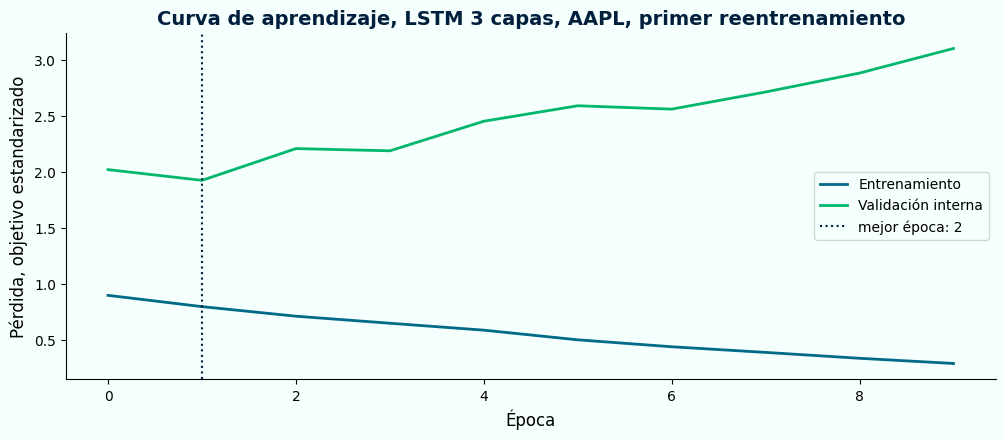

Pronóstico de rendimiento a 21 días para AAPL desde 2023-01-03: +0.50%


In [ ]:
_pred_demo, hist_demo = entrenar_y_predecir(MODELO_PROYECTO, 'AAPL', RETRAIN[0], [RETRAIN[0]], guardar_historia=True)
LOG_ENTRENAMIENTO.pop()   # la demo no forma parte del backtest

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hist_demo['loss'], color=C_WRONG, linewidth=2, label='Entrenamiento')
ax.plot(hist_demo['val_loss'], color=C_RIGHT, linewidth=2, label='Validación interna')
best = int(np.argmin(hist_demo['val_loss']))
ax.axvline(best, color=C_DARK, linestyle=':', label=f'mejor época: {best + 1}')
ax.set_title('Curva de aprendizaje, LSTM 3 capas, AAPL, primer reentrenamiento')
ax.set_xlabel('Época'); ax.set_ylabel('Pérdida, objetivo estandarizado')
ax.legend()
plt.show()
print(f"Pronóstico de rendimiento a 21 días para AAPL desde {idx[RETRAIN[0]].date()}: {np.expm1(_pred_demo[0]):+.2%}")

Si la validación deja de bajar en las primeras épocas, no es un error del código: es la señal honesta de que hay poca estructura que aprender en el precio pasado, lo mismo que anticipaba la gráfica de autocorrelación. El backtest de abajo mide si esa poca estructura alcanza para ganarle a las alternativas simples.

### Backtest de pronósticos: todos los modelos, todas las acciones, todas las fechas

- Cada modelo produce un pronóstico por acción en cada fecha de decisión, usando solo el modelo entrenado en el último reentrenamiento anterior o igual a esa fecha.
- Los resultados se guardan en disco. Si vuelves a correr el notebook con la misma configuración, esta celda los carga en vez de entrenar todo otra vez.

In [ ]:
CONFIG = dict(SYMBOLS=SYMBOLS, FECHA_INICIAL=FECHA_INICIAL, FECHA_FINAL=FECHA_FINAL, INICIO_BACKTEST=INICIO_BACKTEST,
              H=H, WINDOW=WINDOW, RETRAIN_EVERY=RETRAIN_EVERY, VAL_FRAC=VAL_FRAC, EPOCHS_MAX=EPOCHS_MAX,
              PATIENCE=PATIENCE, BATCH_SIZE=BATCH_SIZE, SEED=SEED, MODELOS=list(MODELOS), n_dias=len(idx))
CACHE = f"pronosticos_{hashlib.md5(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:10]}.pkl"

def bloques_de_prediccion():
    """Asigna a cada reentrenamiento las fechas de decisión que le tocan."""
    for k, p_T in enumerate(RETRAIN):
        siguiente = RETRAIN[k + 1] if k + 1 < len(RETRAIN) else len(idx)
        yield p_T, [p for p in REBAL if p_T <= p < siguiente]

if os.path.exists(CACHE):
    with open(CACHE, 'rb') as fh:
        PRONOSTICOS, LOG_ENTRENAMIENTO = pickle.load(fh)
    print("Pronósticos cargados de", CACHE)
else:
    filas = []
    t_inicio = time.time()
    for nombre in MODELOS:
        t_modelo = time.time()
        for activo in SYMBOLS:
            for p_T, pred_pos in bloques_de_prediccion():
                preds = entrenar_y_predecir(nombre, activo, p_T, pred_pos)
                for p, yhat in zip(pred_pos, preds):
                    filas.append((idx[p], activo, nombre, float(yhat)))
        print(f"{nombre:28s} listo en {(time.time() - t_modelo) / 60:5.1f} min")
    PRONOSTICOS = pd.DataFrame(filas, columns=['fecha', 'activo', 'modelo', 'pred'])
    with open(CACHE, 'wb') as fh:
        pickle.dump((PRONOSTICOS, LOG_ENTRENAMIENTO), fh)
    print(f"Total: {(time.time() - t_inicio) / 60:.1f} min. Guardado en {CACHE}")

# Baselines: no se entrenan, se calculan con datos hasta T.
lr_diario = logp.diff()
filas = []
for p in REBAL:
    for activo in SYMBOLS:
        media = lr_diario[activo].iloc[p - LOOKBACK_COV + 1:p + 1].mean() * H
        filas.append((idx[p], activo, 'Media histórica', float(media)))
        filas.append((idx[p], activo, 'Paseo aleatorio', 0.0))
PRONOSTICOS = pd.concat([PRONOSTICOS, pd.DataFrame(filas, columns=PRONOSTICOS.columns)], ignore_index=True)

# Rendimiento real a 21 días, solo para evaluar, nunca como insumo.
PRONOSTICOS['real'] = [OBJETIVO[a].loc[f] for a, f in zip(PRONOSTICOS['activo'], PRONOSTICOS['fecha'])]
assert PRONOSTICOS['real'].notna().all()

# Tabla fecha × acción por modelo, para consultar rápido el pronóstico de una fecha.
PRED = {m: g.pivot(index='fecha', columns='activo', values='pred')[SYMBOLS] for m, g in PRONOSTICOS.groupby('modelo')}
def mu_de(modelo, p):
    """Rendimiento esperado simple a 21 días de cada acción, pronosticado en la fecha p."""
    return np.expm1(PRED[modelo].loc[idx[p]])

PRONOSTICOS.head()

Ridge                        listo en   0.0 min
Gradient Boosting            listo en   0.5 min
LSTM 1 capa                  listo en   4.5 min
LSTM 3 capas                 listo en   7.4 min
GRU 3 capas                  listo en   8.1 min
LSTM 3 capas, solo precio    listo en   9.6 min
Total: 30.1 min. Guardado en pronosticos_f391c179fe.pkl


,fecha,activo,modelo,pred,real
0,2023-01-03,AAPL,Ridge,-0.002417,0.187213
1,2023-02-02,AAPL,Ridge,0.040760,0.021287
2,2023-03-06,AAPL,Ridge,0.030398,0.073908
3,2023-04-04,AAPL,Ridge,0.008710,0.000965
4,2023-05-04,AAPL,Ridge,0.002661,0.081281


## 8. Evaluación, capa técnica: ¿qué modelo pronostica mejor?

Cuatro métricas, porque cada una responde algo distinto:

- **MAE**, error absoluto medio del rendimiento a 21 días. Es la más fácil de leer.
- **R² fuera de muestra contra paseo aleatorio.** `1 − error del modelo / error de pronosticar cero`. Es la métrica estándar en la literatura de predicción de rendimientos. Un valor negativo significa que pronosticar cero habría sido mejor.
- **Acierto de dirección.** Qué tan seguido el modelo acierta si la acción sube o baja.
- **IC, coeficiente de información.** Correlación de rangos entre pronóstico y resultado entre las 10 acciones de cada fecha. Es la que más le importa a un portafolio: no hace falta acertar el número exacto, hace falta ordenar bien qué acción va a rendir más.

In [ ]:
def metricas_pronostico(df):
    err = df['pred'] - df['real']
    sse0 = (df['real'] ** 2).sum()
    ic_fecha = df.groupby('fecha').apply(
        lambda g: spearmanr(g['pred'], g['real'])[0] if g['pred'].nunique() > 1 else np.nan)
    return pd.Series({
        'MAE': err.abs().mean(),
        'R² vs paseo aleatorio': 1 - (err ** 2).sum() / sse0,
        'Acierto de dirección': (np.sign(df['pred']) == np.sign(df['real'])).mean() if df['pred'].abs().sum() > 0 else np.nan,
        'IC medio': ic_fecha.mean(),
        'IC t-stat': ic_fecha.mean() / ic_fecha.std() * np.sqrt(ic_fecha.notna().sum()) if ic_fecha.notna().sum() > 2 else np.nan,
    })

ORDEN = BASELINES + list(MODELOS)
MET_PRON = PRONOSTICOS.groupby('modelo').apply(metricas_pronostico).loc[ORDEN]
seg = pd.DataFrame(LOG_ENTRENAMIENTO).groupby('modelo')['segundos'].sum()
MET_PRON['Minutos de entrenamiento'] = [seg.get(m, 0) / 60 for m in MET_PRON.index]
MET_PRON.style.format({'MAE': '{:.2%}', 'R² vs paseo aleatorio': '{:+.3f}', 'Acierto de dirección': '{:.1%}',
                       'IC medio': '{:+.3f}', 'IC t-stat': '{:+.2f}', 'Minutos de entrenamiento': '{:.1f}'}, na_rep='—')

/tmp/ipykernel_13144/2103230337.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_fecha = df.groupby('fecha').apply(
/tmp/ipykernel_13144/2103230337.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_fecha = df.groupby('fecha').apply(
/tmp/ipykernel_13144/2103230337.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future versio

,MAE,R² vs paseo aleatorio,Acierto de dirección,IC medio,IC t-stat,Minutos de entrenamiento
modelo,,,,,,
Media histórica,8.35%,-0.098,54.7%,+0.065,+0.57,0.0
Paseo aleatorio,8.35%,+0.000,—,—,—,0.0
Ridge,8.39%,+0.013,55.9%,+0.072,+0.95,0.0
Gradient Boosting,8.13%,+0.064,60.0%,-0.065,-1.13,0.5
LSTM 1 capa,8.53%,+0.052,54.1%,+0.034,+0.42,4.5
LSTM 3 capas,8.81%,-0.046,55.3%,-0.010,-0.11,7.4
GRU 3 capas,8.81%,+0.028,54.1%,-0.000,-0.00,8.1
"LSTM 3 capas, solo precio",8.09%,+0.155,55.3%,+0.077,+0.97,9.6


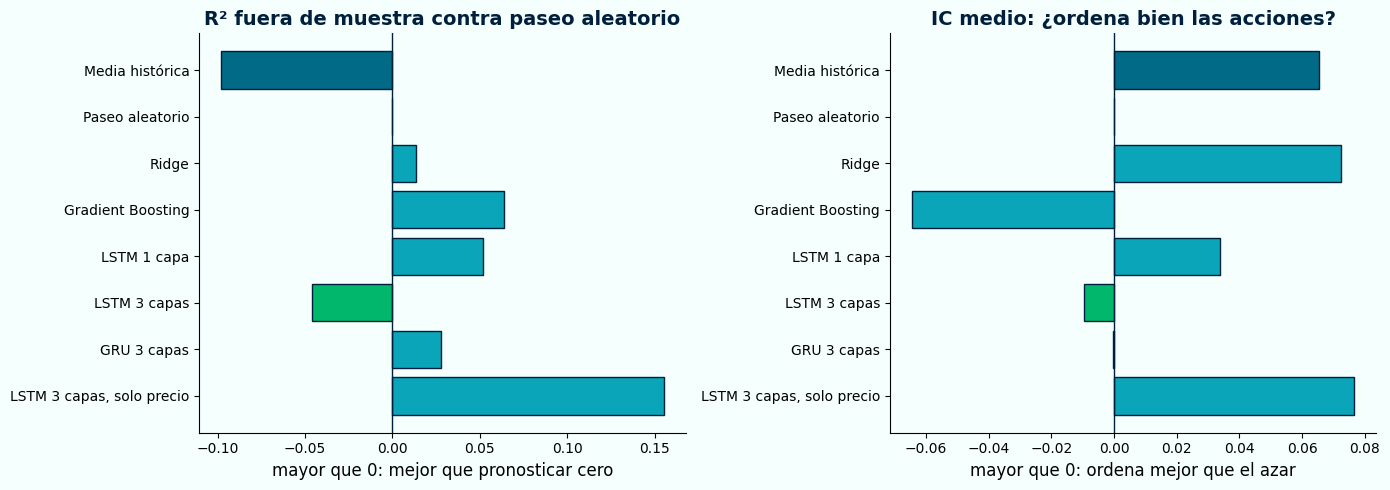

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = MET_PRON.index.tolist()
col = lambda m: C_WRONG if m in BASELINES else (C_RIGHT if m == MODELO_PROYECTO else C_TEAL)
r2 = MET_PRON['R² vs paseo aleatorio']
axes[0].barh(orden, r2, color=[col(m) for m in orden], edgecolor=C_DARK)
axes[0].axvline(0, color=C_DARK, linewidth=1)
axes[0].set_title('R² fuera de muestra contra paseo aleatorio')
axes[0].set_xlabel('mayor que 0: mejor que pronosticar cero')
axes[0].invert_yaxis()
ic = MET_PRON['IC medio'].fillna(0)
axes[1].barh(orden, ic, color=[col(m) for m in orden], edgecolor=C_DARK)
axes[1].axvline(0, color=C_DARK, linewidth=1)
axes[1].set_title('IC medio: ¿ordena bien las acciones?')
axes[1].set_xlabel('mayor que 0: ordena mejor que el azar')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### Resultado de las decisiones del modelo

Las dos decisiones del Explorador que tocan al modelo, leídas directamente de la tabla anterior.

- **¿Solo precio o con indicadores?** Compara `LSTM 3 capas, solo precio` contra `LSTM 3 capas`. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_indicadores)
- **¿Cuántas capas?** Compara `LSTM 1 capa`, `LSTM 3 capas` y `GRU 3 capas`, y las tres contra `Ridge`, que tiene la misma información sin memoria. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_arquitectura)

In [ ]:
d1 = MET_PRON.loc[['LSTM 3 capas, solo precio', 'LSTM 3 capas']]
d2 = MET_PRON.loc[['LSTM 1 capa', 'LSTM 3 capas', 'GRU 3 capas', 'Ridge']]
print("Decisión: ¿solo precio o con indicadores?")
display(d1.style.format('{:.3f}', na_rep='—'))
print("Decisión: ¿cuántas capas y qué celda?")
display(d2.style.format('{:.3f}', na_rep='—'))

Decisión: ¿solo precio o con indicadores?


,MAE,R² vs paseo aleatorio,Acierto de dirección,IC medio,IC t-stat,Minutos de entrenamiento
modelo,,,,,,
"LSTM 3 capas, solo precio",0.081,0.155,0.553,0.077,0.970,9.624
LSTM 3 capas,0.088,-0.046,0.553,-0.010,-0.106,7.434


Decisión: ¿cuántas capas y qué celda?


,MAE,R² vs paseo aleatorio,Acierto de dirección,IC medio,IC t-stat,Minutos de entrenamiento
modelo,,,,,,
LSTM 1 capa,0.085,0.052,0.541,0.034,0.421,4.450
LSTM 3 capas,0.088,-0.046,0.553,-0.010,-0.106,7.434
GRU 3 capas,0.088,0.028,0.541,-0.000,-0.004,8.093
Ridge,0.084,0.013,0.559,0.072,0.947,0.014


## 9. Selección de activos con CAPM

El Modelo de Valoración de Activos de Capital (CAPM) dice cuánto rendimiento hay que exigirle a una acción por el riesgo de mercado que trae:

`rendimiento exigido = tasa libre de riesgo + beta × prima de mercado`

La regla de filtro es comparar ese mínimo contra lo que el modelo pronostica. **Una acción entra al optimizador solo si su rendimiento pronosticado supera su rendimiento exigido**, es decir, si tiene alfa positivo. Todo se mide en el mismo horizonte de 21 días, y beta, la tasa y la prima de mercado se calculan con datos hasta T.

Si menos de 3 acciones pasan, entran las 3 de mayor alfa, para que siempre haya algo que diversificar. El notebook reporta cuántas veces pasa esto.

### Decisión: ¿incluir todos los activos en Markowitz o filtrar antes con CAPM?

Incluir todos los activos deja que Markowitz asigne peso cero a los malos automáticamente, pero el optimizador se vuelve más sensible a errores de estimación. Filtrar primero reduce el universo a activos con premio por riesgo justificado. Aquí se corren las dos opciones.

Si tu universo ya tiene menos de 10 activos, vale la pena preguntarte qué tan justificado sigue estando este filtro. Y sin un benchmark de mercado claro, por ejemplo con cripto o activos alternativos, este es el primer paso que hay que repensar, hay que decidir el proxy de mercado antes de calcular ninguna beta.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-capm_filtro)

In [ ]:
LOG_PORTAFOLIO = []

def capm_en(p):
    """Beta, tasa y prima de mercado con datos hasta la posición p, en horizonte H."""
    v = slice(p - LOOKBACK_BETA + 1, p + 1)
    rf_v = rf_diaria.iloc[v]
    ex_m = ret_mkt.iloc[v] - rf_v
    betas = pd.Series({s: np.cov(ret_simple[s].iloc[v] - rf_v, ex_m)[0, 1] / ex_m.var() for s in SYMBOLS})
    prima_diaria = (ret_mkt.iloc[1:p + 1] - rf_diaria.iloc[1:p + 1]).mean()   # toda la historia hasta T
    rf_H = rf_diaria.iloc[p] * H
    exigido = rf_H + betas * prima_diaria * H
    return betas, exigido, rf_H, ret_mkt.index[v][-1]

def filtro_capm(mu, exigido):
    alfa = mu - exigido
    sel = alfa[alfa > 0].index.tolist()
    forzado = len(sel) < MIN_ACTIVOS
    if forzado:
        sel = alfa.sort_values(ascending=False).index[:MIN_ACTIVOS].tolist()
    return [s for s in SYMBOLS if s in sel], forzado

betas0, exigido0, rf0, _ = capm_en(REBAL[0])
print(f"Ejemplo en {idx[REBAL[0]].date()}: tasa libre de riesgo a 21 días = {rf0:.2%}")
pd.DataFrame({'beta': betas0, 'exigido a 21 días': exigido0}).style.format({'beta': '{:.2f}', 'exigido a 21 días': '{:.2%}'})

Ejemplo en 2023-01-03: tasa libre de riesgo a 21 días = 0.35%


,beta,exigido a 21 días
AAPL,1.31,1.21%
MSFT,1.28,1.19%
GOOGL,1.34,1.23%
AMZN,1.64,1.42%
TSLA,1.76,1.50%
META,1.74,1.49%
NFLX,1.66,1.43%
NVDA,2.21,1.79%
JPM,0.88,0.93%
JNJ,0.30,0.55%


## 10. Optimización de Markowitz

- **Covarianza con Ledoit-Wolf.** Con 252 días y hasta 10 acciones, la covarianza muestral es ruidosa. Ledoit-Wolf la encoge hacia una estructura más estable y es la práctica estándar para no sobreajustar el optimizador.
- **Todo en el mismo horizonte.** Rendimientos esperados, covarianza y tasa libre de riesgo se expresan a 21 días. Mezclar volatilidad diaria con rendimiento mensual haría que cualquier Sharpe no tuviera sentido.
- **Solo posiciones largas.** Pesos entre 0 y 1 que suman 1.

### Decisión: ¿minimizar volatilidad o maximizar el ratio de Sharpe?

Minimizar volatilidad es más conservador y numéricamente más estable, es el punto más a la izquierda de la Frontera Eficiente. Maximizar el ratio de Sharpe busca el mejor balance retorno y riesgo, pero es más sensible a errores en los rendimientos esperados. Aquí se corren las dos opciones, más pesos iguales como referencia.

**Un detalle que cambia la lectura de todo el proyecto:** el portafolio de mínima volatilidad depende solo de la covarianza, no de los rendimientos esperados. Si el optimizador minimiza volatilidad sobre todas las acciones, el pronóstico del modelo no mueve ni un peso. El pronóstico solo influye si decide qué acciones entran, que es lo que hace el filtro CAPM, o si el objetivo lo usa, que es lo que hace el máximo Sharpe. La celda de verificación de abajo lo comprueba con dos pronósticos distintos.

Si tus rendimientos esperados vinieran de guía oficial de la empresa en vez de una predicción, valdría la pena reconsiderar el objetivo. Cambiarlo es un ajuste local dentro de la llamada a `scipy.optimize.minimize`, el resto del pipeline no cambia.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-markowitz_objetivo)

In [ ]:
def cov_en(p, activos):
    v = slice(p - LOOKBACK_COV + 1, p + 1)
    R = ret_simple[activos].iloc[v]
    assert R.index[-1] == idx[p] and R.notna().all().all()
    return LedoitWolf().fit(R.values).covariance_ * H

def _resolver(fun, n):
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    mejor = None
    for w0 in [np.repeat(1 / n, n), np.random.default_rng(SEED).dirichlet(np.ones(n))]:
        r = minimize(fun, w0, method='SLSQP', bounds=[(0, 1)] * n, constraints=cons,
                     options={'ftol': 1e-12, 'maxiter': 1000})
        if r.success and (mejor is None or r.fun < mejor.fun):
            mejor = r
    assert mejor is not None, "El optimizador no convergió"
    w = np.clip(mejor.x, 0, None)
    return w / w.sum()

def min_vol(S):
    return _resolver(lambda w: w @ S @ w, len(S))

def max_sharpe(mu, S, rf):
    if np.max(mu) <= rf:
        return min_vol(S), True          # ningún activo supera la tasa: Sharpe máximo no está definido
    return _resolver(lambda w: -(w @ mu - rf) / np.sqrt(w @ S @ w), len(S)), False

# Verificación de la lección: mínima volatilidad sin filtro ignora el pronóstico.
p_chk = REBAL[0]
S_chk = cov_en(p_chk, SYMBOLS)
w_mv_chk = min_vol(S_chk)   # min_vol solo recibe la covarianza: no hay dónde meter un pronóstico
ws_a, _ = max_sharpe(mu_de(MODELO_PROYECTO, p_chk).values, S_chk, rf_diaria.iloc[p_chk] * H)
ws_b, _ = max_sharpe(mu_de('Media histórica', p_chk).values, S_chk, rf_diaria.iloc[p_chk] * H)
print("Mínima volatilidad: mismos pesos con cualquier pronóstico, porque solo depende de la covarianza")
print("   ", dict(zip(SYMBOLS, np.round(w_mv_chk, 3))))
print("Máximo Sharpe con pronóstico LSTM vs media histórica: diferencia total de pesos =", round(float(np.abs(ws_a - ws_b).sum()), 3))

Mínima volatilidad: mismos pesos con cualquier pronóstico, porque solo depende de la covarianza
    {'AAPL': np.float64(0.0), 'MSFT': np.float64(0.043), 'GOOGL': np.float64(0.024), 'AMZN': np.float64(0.0), 'TSLA': np.float64(0.011), 'META': np.float64(0.0), 'NFLX': np.float64(0.0), 'NVDA': np.float64(0.0), 'JPM': np.float64(0.153), 'JNJ': np.float64(0.769)}
Máximo Sharpe con pronóstico LSTM vs media histórica: diferencia total de pesos = 2.0


## 11. Evaluación, capa de negocio: backtest de portafolios

Cada estrategia se construye en cada fecha de decisión con la información disponible ese día, se mantiene 21 días y se mide con el rendimiento real de esos días.

- **Referencias que no usan pronóstico:** S&P 500, pesos iguales, y mínima volatilidad sobre las 10 acciones.
- **Por cada modelo de pronóstico:** filtro CAPM + mínima volatilidad, que es el pipeline original del proyecto, máximo Sharpe sin filtro, y filtro CAPM + máximo Sharpe.
- **Costos:** cada rebalanceo paga 10 puntos base por unidad de rotación. Una estrategia que cambia todo cada mes paga más.
- **Métricas:** rendimiento y volatilidad anualizados, Sharpe en exceso de la tasa libre de riesgo, caída máxima, rotación y número de activos con peso.

In [ ]:
def pesos_estrategia(estrategia, modelo, p):
    """Devuelve pesos sobre las 10 acciones y metadatos, usando solo datos hasta p."""
    info = {}
    if estrategia == 'Pesos iguales':
        return pd.Series(1 / len(SYMBOLS), index=SYMBOLS), info
    if estrategia == 'Mín. volatilidad, 10 acciones':
        return pd.Series(min_vol(cov_en(p, SYMBOLS)), index=SYMBOLS), info
    mu = mu_de(modelo, p)
    betas, exigido, rf_H, fin_beta = capm_en(p)
    info['fin_beta'] = fin_beta
    activos = SYMBOLS
    if 'CAPM' in estrategia:
        activos, info['forzado'] = filtro_capm(mu, exigido)
    S = cov_en(p, activos)
    if 'mín. volatilidad' in estrategia:
        w = min_vol(S)
    else:
        w, info['sharpe_indefinido'] = max_sharpe(mu[activos].values, S, rf_H)
    return pd.Series(w, index=activos).reindex(SYMBOLS).fillna(0.0), info

def correr_backtest(estrategia, modelo=None):
    diarios, rotaciones, n_activos, max_peso = [], [], [], []
    w_prev = pd.Series(0.0, index=SYMBOLS)
    for p in REBAL:
        w, info = pesos_estrategia(estrategia, modelo, p)
        assert abs(w.sum() - 1) < 1e-6 and (w >= -1e-9).all(), "Pesos inválidos"
        R = ret_simple.iloc[p + 1:p + H + 1]              # el periodo de tenencia empieza después de T
        assert R.index[0] > idx[p]
        crecimiento = (1 + R).cumprod()
        valor = (crecimiento * w).sum(axis=1)
        r = valor.pct_change()
        r.iloc[0] = valor.iloc[0] - 1
        rot = float((w - w_prev).abs().sum())
        r.iloc[0] -= COSTO_TRANSACCION * rot
        diarios.append(r)
        rotaciones.append(rot); n_activos.append(int((w > 1e-4).sum())); max_peso.append(float(w.max()))
        w_prev = (w * crecimiento.iloc[-1]) / (w * crecimiento.iloc[-1]).sum()   # pesos a la deriva al cierre
        LOG_PORTAFOLIO.append({'estrategia': estrategia, 'modelo': modelo, 'p': p,
                               'fin_beta': info.get('fin_beta'), 'inicio_tenencia': R.index[0],
                               'forzado': info.get('forzado', False),
                               'sharpe_indefinido': info.get('sharpe_indefinido', False),
                               'pesos': w.round(4).to_dict()})
    serie = pd.concat(diarios)
    return serie, dict(rotacion=np.mean(rotaciones[1:]), n_activos=np.mean(n_activos), max_peso=np.mean(max_peso))

ESTRATEGIAS = {}
ESTRATEGIAS['S&P 500'] = (ret_mkt.loc[idx[REBAL[0] + 1]:idx[REBAL[-1] + H]], dict(rotacion=0, n_activos=np.nan, max_peso=np.nan))
ESTRATEGIAS['Pesos iguales'] = correr_backtest('Pesos iguales')
ESTRATEGIAS['Mín. volatilidad, 10 acciones'] = correr_backtest('Mín. volatilidad, 10 acciones')
for m in ['Media histórica'] + list(MODELOS):
    for e in ['CAPM + mín. volatilidad', 'Máx. Sharpe', 'CAPM + máx. Sharpe']:
        ESTRATEGIAS[f"{m} | {e}"] = correr_backtest(e, m)
print(f"{len(ESTRATEGIAS)} estrategias evaluadas sobre {len(ESTRATEGIAS['Pesos iguales'][0])} días fuera de muestra")

24 estrategias evaluadas sobre 357 días fuera de muestra


In [ ]:
rf_serie = rf_diaria.reindex(ESTRATEGIAS['Pesos iguales'][0].index)

def metricas_portafolio(r):
    ex = r - rf_serie.reindex(r.index)
    valor = (1 + r).cumprod()
    return {
        'Rend. anual': valor.iloc[-1] ** (252 / len(r)) - 1,
        'Volatilidad anual': r.std() * np.sqrt(252),
        'Sharpe': ex.mean() / ex.std() * np.sqrt(252),
        'Caída máxima': (valor / valor.cummax() - 1).min(),
    }

def bootstrap_sharpe(r, ref, n=N_BOOTSTRAP, bloque=H):
    """Bootstrap circular por bloques de 21 días: respeta que los días de un
    mismo mes no son independientes. Devuelve intervalo del Sharpe y la
    probabilidad de que la estrategia supere a la referencia."""
    rng = np.random.default_rng(SEED)
    ex = (r - rf_serie.reindex(r.index)).values
    ex_ref = (ref - rf_serie.reindex(ref.index)).values
    T = len(ex); k = int(np.ceil(T / bloque))
    sh, gana = [], 0
    for _ in range(n):
        ini = rng.integers(0, T, k)
        ii = (ini[:, None] + np.arange(bloque)[None, :]).ravel()[:T] % T
        a, b = ex[ii], ex_ref[ii]
        s_a = a.mean() / a.std() * np.sqrt(252); s_b = b.mean() / b.std() * np.sqrt(252)
        sh.append(s_a); gana += s_a > s_b
    return np.percentile(sh, 2.5), np.percentile(sh, 97.5), gana / n

ref = ESTRATEGIAS['Pesos iguales'][0]
filas = []
for nombre, (r, extra) in ESTRATEGIAS.items():
    m = metricas_portafolio(r)
    lo, hi, p_gana = bootstrap_sharpe(r, ref)
    filas.append({'Estrategia': nombre, **m, 'Sharpe IC 95% bajo': lo, 'Sharpe IC 95% alto': hi,
                  'P(Sharpe > pesos iguales)': p_gana, 'Rotación mensual': extra['rotacion'],
                  'Activos con peso': extra['n_activos'], 'Peso máximo': extra['max_peso']})
MET_PORT = pd.DataFrame(filas).set_index('Estrategia')
MET_PORT.sort_values('Sharpe', ascending=False).style.format({
    'Rend. anual': '{:.1%}', 'Volatilidad anual': '{:.1%}', 'Sharpe': '{:.2f}', 'Caída máxima': '{:.1%}',
    'Sharpe IC 95% bajo': '{:.2f}', 'Sharpe IC 95% alto': '{:.2f}', 'P(Sharpe > pesos iguales)': '{:.0%}',
    'Rotación mensual': '{:.2f}', 'Activos con peso': '{:.1f}', 'Peso máximo': '{:.0%}'}, na_rep='—')

,Rend. anual,Volatilidad anual,Sharpe,Caída máxima,Sharpe IC 95% bajo,Sharpe IC 95% alto,P(Sharpe > pesos iguales),Rotación mensual,Activos con peso,Peso máximo
Estrategia,,,,,,,,,,
Pesos iguales,78.5%,20.2%,2.72,-11.2%,1.20,4.41,0%,0.06,10.0,10%
Gradient Boosting | Máx. Sharpe,85.4%,25.4%,2.36,-14.1%,0.78,3.94,16%,0.89,3.3,63%
Gradient Boosting | CAPM + máx. Sharpe,83.2%,25.3%,2.32,-14.3%,0.78,3.91,14%,0.91,3.1,64%
"LSTM 3 capas, solo precio | CAPM + máx. Sharpe",128.4%,37.0%,2.28,-21.3%,0.32,4.18,23%,1.43,2.6,71%
Ridge | CAPM + máx. Sharpe,75.5%,24.0%,2.26,-17.4%,0.56,3.93,20%,1.45,2.7,67%
Ridge | Máx. Sharpe,74.6%,23.8%,2.25,-17.4%,0.55,3.91,20%,1.45,2.8,67%
"LSTM 3 capas, solo precio | Máx. Sharpe",119.0%,36.2%,2.21,-21.5%,0.26,4.09,20%,1.43,2.9,70%
GRU 3 capas | CAPM + máx. Sharpe,73.7%,30.3%,1.80,-21.1%,-0.29,3.61,9%,1.54,2.2,77%
LSTM 1 capa | CAPM + mín. volatilidad,37.6%,15.8%,1.78,-15.6%,0.02,3.50,6%,1.14,3.4,64%


- El intervalo del Sharpe es ancho a propósito: 18 meses son pocos para separar habilidad de suerte. Si los intervalos de dos estrategias se traslapan mucho, **la diferencia no está demostrada**, y el notebook no la vende como si lo estuviera.
- `P(Sharpe > pesos iguales)` resume lo mismo en un número: 50% significa que, con esta muestra, no se distingue de repartir el dinero en partes iguales.

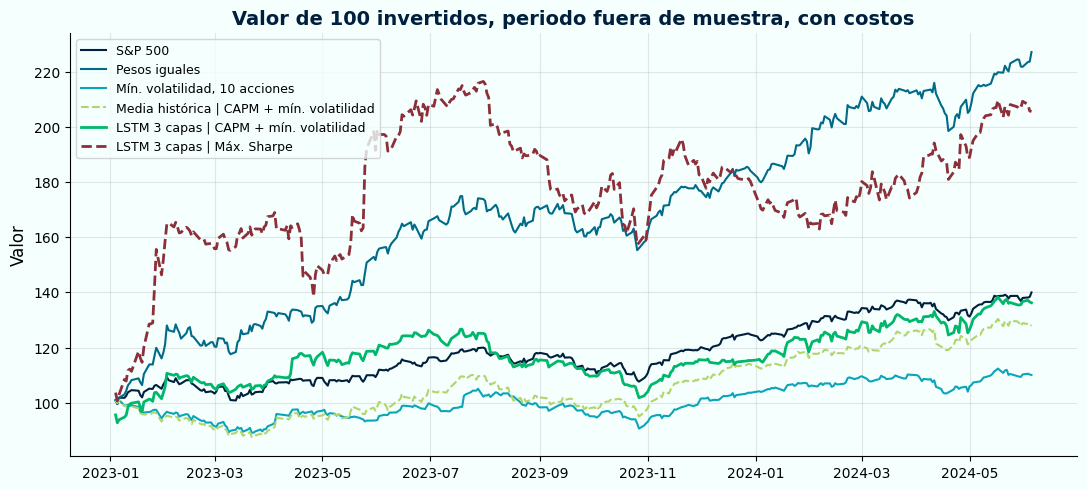

In [ ]:
mostrar = ['S&P 500', 'Pesos iguales', 'Mín. volatilidad, 10 acciones',
           f'Media histórica | CAPM + mín. volatilidad',
           f'{MODELO_PROYECTO} | CAPM + mín. volatilidad', f'{MODELO_PROYECTO} | Máx. Sharpe']
colores = [C_DARK, C_WRONG, C_TEAL, C_LIME, C_RIGHT, C_ERROR]
estilos = ['-', '-', '-', '--', '-', '--']
fig, ax = plt.subplots(figsize=(13, 5.5))
for nombre, c, ls in zip(mostrar, colores, estilos):
    v = (1 + ESTRATEGIAS[nombre][0]).cumprod() * 100
    ax.plot(v.index, v.values, color=c, linestyle=ls, linewidth=2 if nombre.startswith(MODELO_PROYECTO) else 1.5, label=nombre)
ax.set_title('Valor de 100 invertidos, periodo fuera de muestra, con costos')
ax.set_ylabel('Valor'); ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
plt.show()

### Resultado de las decisiones del portafolio

- **¿Filtrar con CAPM?** Con mínima volatilidad: `Mín. volatilidad, 10 acciones` contra `LSTM 3 capas | CAPM + mín. volatilidad`. Con máximo Sharpe: `LSTM 3 capas | Máx. Sharpe` contra `LSTM 3 capas | CAPM + máx. Sharpe`. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-capm_filtro)
- **¿Mínima volatilidad o máximo Sharpe?** Con el mismo modelo y el mismo filtro, más pesos iguales como referencia. [Explorador](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-markowitz_objetivo)

In [ ]:
cols = ['Rend. anual', 'Volatilidad anual', 'Sharpe', 'Caída máxima', 'P(Sharpe > pesos iguales)', 'Activos con peso']
fmt = {'Rend. anual': '{:.1%}', 'Volatilidad anual': '{:.1%}', 'Sharpe': '{:.2f}', 'Caída máxima': '{:.1%}',
       'P(Sharpe > pesos iguales)': '{:.0%}', 'Activos con peso': '{:.1f}'}
d3 = MET_PORT.loc[['Mín. volatilidad, 10 acciones', f'{MODELO_PROYECTO} | CAPM + mín. volatilidad',
                   f'{MODELO_PROYECTO} | Máx. Sharpe', f'{MODELO_PROYECTO} | CAPM + máx. Sharpe'], cols]
d4 = MET_PORT.loc[[f'{MODELO_PROYECTO} | CAPM + mín. volatilidad', f'{MODELO_PROYECTO} | CAPM + máx. Sharpe', 'Pesos iguales'], cols]
print("Decisión: ¿filtrar con CAPM?")
display(d3.style.format(fmt))
print("Decisión: ¿mínima volatilidad o máximo Sharpe?")
display(d4.style.format(fmt))

lp = pd.DataFrame(LOG_PORTAFOLIO)
capm = lp[lp['estrategia'].str.contains('CAPM')]
print(f"Fechas en que menos de {MIN_ACTIVOS} acciones pasaron el filtro y se tomaron las de mayor alfa: "
      f"{capm['forzado'].mean():.0%} de los casos")
print(f"Fechas en que ningún activo superaba la tasa y máx. Sharpe cayó a mín. volatilidad: "
      f"{lp[lp['estrategia'].str.contains('Sharpe')]['sharpe_indefinido'].mean():.0%} de los casos")

Decisión: ¿filtrar con CAPM?


,Rend. anual,Volatilidad anual,Sharpe,Caída máxima,P(Sharpe > pesos iguales),Activos con peso
Estrategia,,,,,,
"Mín. volatilidad, 10 acciones",7.0%,12.6%,0.19,-13.7%,0%,6.2
LSTM 3 capas | CAPM + mín. volatilidad,24.4%,18.2%,1.01,-19.6%,0%,3.3
LSTM 3 capas | Máx. Sharpe,66.3%,34.3%,1.50,-27.3%,2%,2.2
LSTM 3 capas | CAPM + máx. Sharpe,66.4%,34.3%,1.50,-27.4%,2%,2.2


Decisión: ¿mínima volatilidad o máximo Sharpe?


,Rend. anual,Volatilidad anual,Sharpe,Caída máxima,P(Sharpe > pesos iguales),Activos con peso
Estrategia,,,,,,
LSTM 3 capas | CAPM + mín. volatilidad,24.4%,18.2%,1.01,-19.6%,0%,3.3
LSTM 3 capas | CAPM + máx. Sharpe,66.4%,34.3%,1.50,-27.4%,2%,2.2
Pesos iguales,78.5%,20.2%,2.72,-11.2%,0%,10.0


Fechas en que menos de 3 acciones pasaron el filtro y se tomaron las de mayor alfa: 18% de los casos
Fechas en que ningún activo superaba la tasa y máx. Sharpe cayó a mín. volatilidad: 2% de los casos


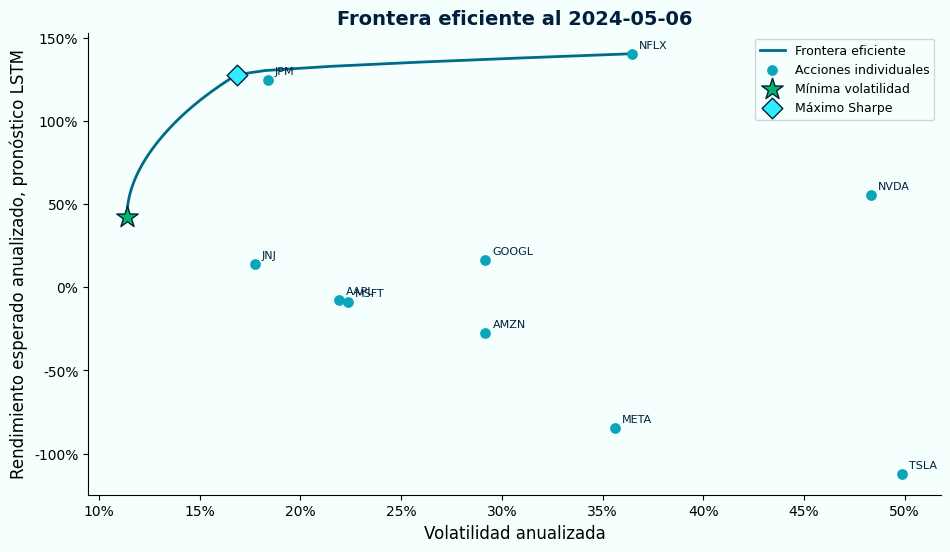

In [ ]:
# Frontera eficiente en la última fecha de decisión, en unidades anualizadas.
p_last = REBAL[-1]
mu_last = mu_de(MODELO_PROYECTO, p_last)
S_last = cov_en(p_last, SYMBOLS)
rf_last = rf_diaria.iloc[p_last] * H
esc_r, esc_v = 252 / H, np.sqrt(252 / H)

w_mv = min_vol(S_last)
w_ms, _ = max_sharpe(mu_last.values, S_last, rf_last)
r_min = w_mv @ mu_last.values
objetivos = np.linspace(r_min, mu_last.max(), 40)
frontera, w0 = [], w_mv.copy()
for t in objetivos:
    cons = ({'type': 'eq', 'fun': lambda w: w.sum() - 1}, {'type': 'eq', 'fun': lambda w, t=t: w @ mu_last.values - t})
    res = minimize(lambda w: w @ S_last @ w, w0, method='SLSQP', bounds=[(0, 1)] * 10, constraints=cons,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    if res.success:
        w0 = res.x                                  # arranque en caliente desde el punto anterior
        frontera.append((np.sqrt(res.x @ S_last @ res.x), t))
frontera = np.array(frontera)
if len(frontera):                                   # solo la rama eficiente: volatilidad no decreciente
    frontera = frontera[np.maximum.accumulate(frontera[:, 0]) <= frontera[:, 0] + 1e-9]

fig, ax = plt.subplots(figsize=(11, 6))
if len(frontera):
    ax.plot(frontera[:, 0] * esc_v, frontera[:, 1] * esc_r, color=C_WRONG, linewidth=2, label='Frontera eficiente')
vol_ind = np.sqrt(np.diag(S_last))
ax.scatter(vol_ind * esc_v, mu_last.values * esc_r, color=C_TEAL, s=45, zorder=4, label='Acciones individuales')
for s, x, yv in zip(SYMBOLS, vol_ind * esc_v, mu_last.values * esc_r):
    ax.annotate(s, (x, yv), textcoords='offset points', xytext=(5, 4), fontsize=8, color=C_DARK)
ax.scatter(np.sqrt(w_mv @ S_last @ w_mv) * esc_v, (w_mv @ mu_last.values) * esc_r, marker='*', s=260,
           color=C_RIGHT, edgecolor=C_DARK, zorder=5, label='Mínima volatilidad')
ax.scatter(np.sqrt(w_ms @ S_last @ w_ms) * esc_v, (w_ms @ mu_last.values) * esc_r, marker='D', s=110,
           color=C_ACCENT, edgecolor=C_DARK, zorder=5, label='Máximo Sharpe')
ax.set_xlabel('Volatilidad anualizada'); ax.set_ylabel('Rendimiento esperado anualizado, pronóstico LSTM')
ax.set_title(f'Frontera eficiente al {idx[p_last].date()}')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=9)
plt.show()

## 12. Exportación para el Explorador de decisiones

- Los resultados de cada alternativa se guardan en `explorador_resultados.json`, con las mismas etiquetas de opción que usa el Explorador del artículo.
- Así el sitio y el notebook salen de la misma fuente: si cambias algo aquí y vuelves a correr, el Explorador muestra los números nuevos.
- También se guardan las tablas completas en CSV.

In [ ]:
def _num(x, nd):
    x = float(x)
    return None if not np.isfinite(x) else round(x, nd)

def _pron(m):
    r = MET_PRON.loc[m]
    return {'r2_oos': _num(r['R² vs paseo aleatorio'], 4), 'ic': _num(r['IC medio'], 4),
            'acierto_direccion': _num(r['Acierto de dirección'], 4), 'mae': _num(r['MAE'], 4),
            'minutos_entrenamiento': _num(r['Minutos de entrenamiento'], 1)}

def _port(e):
    r = MET_PORT.loc[e]
    return {'sharpe': _num(r['Sharpe'], 3), 'sharpe_ic95': [_num(r['Sharpe IC 95% bajo'], 3), _num(r['Sharpe IC 95% alto'], 3)],
            'rend_anual': _num(r['Rend. anual'], 4), 'vol_anual': _num(r['Volatilidad anual'], 4),
            'caida_maxima': _num(r['Caída máxima'], 4), 'p_supera_pesos_iguales': _num(r['P(Sharpe > pesos iguales)'], 3),
            'activos_con_peso': _num(r['Activos con peso'], 1)}

EXPLORADOR = {
    'meta': {'ejecutado': datetime.now().strftime('%Y-%m-%d'), 'periodo_fuera_de_muestra':
             [str(idx[REBAL[0] + 1].date()), str(idx[REBAL[-1] + H].date())], 'fechas_decision': len(REBAL),
             'config': CONFIG},
    'lstm_indicadores': {'Solo precio de cierre': _pron('LSTM 3 capas, solo precio'),
                         'Con 4 indicadores técnicos': _pron('LSTM 3 capas')},
    'lstm_arquitectura': {'Una sola capa (50 unidades)': _pron('LSTM 1 capa'),
                          'Tres capas apiladas + Dropout': _pron('LSTM 3 capas'),
                          'GRU de tres capas': _pron('GRU 3 capas'),
                          'Ridge con la misma ventana': _pron('Ridge')},
    'capm_filtro': {'Incluir todos los activos': _port('Mín. volatilidad, 10 acciones'),
                    'Filtrar primero con CAPM': _port(f'{MODELO_PROYECTO} | CAPM + mín. volatilidad')},
    'markowitz_objetivo': {'Mínima volatilidad': _port(f'{MODELO_PROYECTO} | CAPM + mín. volatilidad'),
                           'Máximo ratio de Sharpe': _port(f'{MODELO_PROYECTO} | CAPM + máx. Sharpe'),
                           'Pesos iguales (referencia)': _port('Pesos iguales')},
    'modelos_vs_baselines': {m: _pron(m) for m in MET_PRON.index},
}
with open('explorador_resultados.json', 'w', encoding='utf-8') as fh:
    json.dump(EXPLORADOR, fh, ensure_ascii=False, indent=2, allow_nan=False)
MET_PRON.to_csv('metricas_pronostico.csv')
MET_PORT.to_csv('metricas_portafolio.csv')
print(json.dumps({k: v for k, v in EXPLORADOR.items() if k != 'meta'}, ensure_ascii=False, indent=1)[:1500], '...')

{
 "lstm_indicadores": {
  "Solo precio de cierre": {
   "r2_oos": 0.155,
   "ic": 0.0766,
   "acierto_direccion": 0.5529,
   "mae": 0.0809,
   "minutos_entrenamiento": 9.6
  },
  "Con 4 indicadores técnicos": {
   "r2_oos": -0.0459,
   "ic": -0.0096,
   "acierto_direccion": 0.5529,
   "mae": 0.0881,
   "minutos_entrenamiento": 7.4
  }
 },
 "lstm_arquitectura": {
  "Una sola capa (50 unidades)": {
   "r2_oos": 0.052,
   "ic": 0.0339,
   "acierto_direccion": 0.5412,
   "mae": 0.0853,
   "minutos_entrenamiento": 4.5
  },
  "Tres capas apiladas + Dropout": {
   "r2_oos": -0.0459,
   "ic": -0.0096,
   "acierto_direccion": 0.5529,
   "mae": 0.0881,
   "minutos_entrenamiento": 7.4
  },
  "GRU de tres capas": {
   "r2_oos": 0.0276,
   "ic": -0.0004,
   "acierto_direccion": 0.5412,
   "mae": 0.0881,
   "minutos_entrenamiento": 8.1
  },
  "Ridge con la misma ventana": {
   "r2_oos": 0.0134,
   "ic": 0.0724,
   "acierto_direccion": 0.5588,
   "mae": 0.0839,
   "minutos_entrenamiento": 0.0
  }
 }

## Checklist metodológico

Cada punto se verifica con código en la celda siguiente. Si alguno falla, la celda se detiene con un error en vez de dejar pasar un resultado contaminado.

- **Sin fuga en el escalado.** Cada scaler se ajustó con filas que terminan antes del inicio de la validación y antes de T, y sus medias coinciden con las de esas filas.
- **Purga del objetivo.** Ningún objetivo usado en entrenamiento termina después de T.
- **Embargo.** Ningún objetivo del ajuste se traslapa con el periodo de validación.
- **Pronóstico hacia adelante.** Todo pronóstico se hizo en una fecha igual o posterior al reentrenamiento que lo produjo.
- **Indicadores sin mirar el futuro.** Recalcular los indicadores con la serie recortada en T da exactamente el mismo valor en T que calcularlos sobre la serie completa.
- **El objetivo es lo que dice ser.** El valor del objetivo coincide con el rendimiento logarítmico a 21 días recalculado desde los precios.
- **CAPM y covarianza con datos hasta T.** Toda beta termina en T y todo periodo de tenencia empieza después de T.
- **Pesos válidos.** Todos suman 1 y ninguno es negativo.
- **Cobertura completa.** Cada modelo tiene un pronóstico por acción y por fecha de decisión.

In [ ]:
le = pd.DataFrame(LOG_ENTRENAMIENTO)
lp = pd.DataFrame(LOG_PORTAFOLIO)
rng = np.random.default_rng(SEED)

assert (le['fin_scaler'] < le['inicio_val']).all() and (le['fin_scaler'] <= le['p_T']).all(), "Scaler ajustado con datos de validación o posteriores a T"
assert (le['fin_objetivo_train'] <= le['p_T']).all(), "Un objetivo de entrenamiento termina después de T"
assert (le['fin_fit_mas_H'] < le['inicio_val']).all(), "El ajuste y la validación se traslapan"
assert (le['min_pred_pos'] >= le['p_T']).all(), "Se pronosticó antes del entrenamiento que produjo el pronóstico"

for _ in range(15):
    s = rng.choice(SYMBOLS); p = int(rng.choice(REBAL))
    completo = FEATURES[s].iloc[p]
    recortado = calcular_features(precios[s].iloc[:p + 1]).iloc[-1]
    assert np.allclose(completo.values, recortado.values, equal_nan=True), f"Indicador de {s} mira el futuro en {idx[p].date()}"

for _ in range(15):
    s = rng.choice(SYMBOLS); p = int(rng.choice(REBAL))
    assert np.isclose(OBJETIVO[s].iloc[p], np.log(precios[s].iloc[p + H] / precios[s].iloc[p])), "El objetivo no es el rendimiento a 21 días"

con_beta = lp.dropna(subset=['fin_beta'])
assert all(fb == idx[p] for fb, p in zip(con_beta['fin_beta'], con_beta['p'])), "Una beta usa datos posteriores a T"
assert all(it > idx[p] for it, p in zip(lp['inicio_tenencia'], lp['p'])), "Un periodo de tenencia empieza antes de T"
assert all(abs(sum(w.values()) - 1) < 1e-3 and min(w.values()) >= 0 for w in lp['pesos']), "Pesos inválidos"

cobertura = PRONOSTICOS.groupby('modelo').size()
assert (cobertura == len(REBAL) * len(SYMBOLS)).all(), "Falta algún pronóstico"

print("Checklist metodológico verificado:")
print(f"- {len(le)} entrenamientos auditados: escalado, purga, embargo y orden temporal correctos")
print(f"- 15 recálculos de indicadores sobre series recortadas coinciden con la serie completa")
print(f"- 15 objetivos recalculados desde precios coinciden")
print(f"- {len(lp)} portafolios auditados: beta hasta T, tenencia después de T, pesos válidos")
print(f"- {len(cobertura)} modelos con {len(REBAL)} × {len(SYMBOLS)} pronósticos cada uno")

Checklist metodológico verificado:
- 360 entrenamientos auditados: escalado, purga, embargo y orden temporal correctos
- 15 recálculos de indicadores sobre series recortadas coinciden con la serie completa
- 15 objetivos recalculados desde precios coinciden
- 391 portafolios auditados: beta hasta T, tenencia después de T, pesos válidos
- 8 modelos con 17 × 10 pronósticos cada uno


## Resumen automático de resultados

Esta celda redacta los hallazgos con los números de esta corrida, para que la conclusión nunca se escriba antes de ver el resultado.

In [ ]:
r2 = MET_PRON['R² vs paseo aleatorio']
ml = list(MODELOS)
mejor = r2[ml].idxmax()
hm = r2['Media histórica']
sh = MET_PORT['Sharpe']
pipe = f'{MODELO_PROYECTO} | CAPM + mín. volatilidad'

print(f"• Mejor modelo por R² fuera de muestra: {mejor} ({r2[mejor]:+.3f}); media histórica: {hm:+.3f}.")
print(f"• Modelos que superan al paseo aleatorio: {', '.join(r2[ml][r2[ml] > 0].index) or 'ninguno'}.")
print(f"• Modelos que superan a la media histórica: {', '.join(r2[ml][r2[ml] > hm].index) or 'ninguno'}.")
print(f"• IC del modelo del proyecto: {MET_PRON.loc[MODELO_PROYECTO, 'IC medio']:+.3f} (t = {MET_PRON.loc[MODELO_PROYECTO, 'IC t-stat']:+.2f}).")
print(f"• Indicadores vs solo precio en LSTM 3 capas: R² {r2['LSTM 3 capas']:+.3f} vs {r2['LSTM 3 capas, solo precio']:+.3f}.")
print(f"• Profundidad y celda: LSTM 1 capa {r2['LSTM 1 capa']:+.3f}, LSTM 3 capas {r2['LSTM 3 capas']:+.3f}, GRU 3 capas {r2['GRU 3 capas']:+.3f}, Ridge {r2['Ridge']:+.3f}.")
print(f"• Pipeline del proyecto, Sharpe {sh[pipe]:.2f} (IC 95% {MET_PORT.loc[pipe, 'Sharpe IC 95% bajo']:.2f} a {MET_PORT.loc[pipe, 'Sharpe IC 95% alto']:.2f}); "
      f"pesos iguales {sh['Pesos iguales']:.2f}; S&P 500 {sh['S&P 500']:.2f}; mín. volatilidad sin filtro {sh['Mín. volatilidad, 10 acciones']:.2f}.")
print(f"• Máximo Sharpe con el mismo modelo y filtro: {sh[f'{MODELO_PROYECTO} | CAPM + máx. Sharpe']:.2f}.")
top = sh.drop(['S&P 500']).idxmax()
print(f"• Estrategia con mayor Sharpe: {top} ({sh[top]:.2f}), P(> pesos iguales) = {MET_PORT.loc[top, 'P(Sharpe > pesos iguales)']:.0%}.")

• Mejor modelo por R² fuera de muestra: LSTM 3 capas, solo precio (+0.155); media histórica: -0.098.
• Modelos que superan al paseo aleatorio: Ridge, Gradient Boosting, LSTM 1 capa, GRU 3 capas, LSTM 3 capas, solo precio.
• Modelos que superan a la media histórica: Ridge, Gradient Boosting, LSTM 1 capa, LSTM 3 capas, GRU 3 capas, LSTM 3 capas, solo precio.
• IC del modelo del proyecto: -0.010 (t = -0.11).
• Indicadores vs solo precio en LSTM 3 capas: R² -0.046 vs +0.155.
• Profundidad y celda: LSTM 1 capa +0.052, LSTM 3 capas -0.046, GRU 3 capas +0.028, Ridge +0.013.
• Pipeline del proyecto, Sharpe 1.01 (IC 95% -0.55 a 2.55); pesos iguales 2.72; S&P 500 1.55; mín. volatilidad sin filtro 0.19.
• Máximo Sharpe con el mismo modelo y filtro: 1.50.
• Estrategia con mayor Sharpe: Pesos iguales (2.72), P(> pesos iguales) = 0%.


## Hallazgos y siguientes pasos

Los números concretos de esta corrida están en el resumen automático de arriba. Lo que el diseño del experimento deja claro, sin importar qué modelo gane:

- **Un modelo solo vale lo que gana contra la alternativa simple.** La media histórica y el paseo aleatorio son la vara. Sin ellos, cualquier MSE bajo parece un logro.
- **El pronóstico tiene que llegar a los pesos.** Mínima volatilidad sobre todo el universo ignora el pronóstico por completo. El modelo solo influye a través del filtro CAPM o de un objetivo que use rendimientos, como el máximo Sharpe.
- **La evaluación que importa es la del portafolio, fuera de muestra y con costos.** Un buen R² que no mejora el Sharpe no le sirve a quien invierte, y un Sharpe mejor que no sale del intervalo de confianza todavía no es una conclusión.
- **Pronosticar rendimientos y no precios** evita el problema de extrapolar fuera del rango de entrenamiento que tenía la primera versión.

Si quieres ir más allá:

- Revisa las 4 decisiones exploradas en este notebook, con su alternativa y el resultado que hubieras obtenido, en el [artículo completo](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/).
- Lee la sección "Cómo adaptarlo" del artículo para ver qué cambiaría con tu propio universo de activos, tu propio proxy de mercado o tu propio objetivo de optimización.
- El repositorio en GitHub tiene el diagrama editable del pipeline y el README con las referencias académicas de cada decisión.

<br>

## Siguientes pasos: de caso de estudio a proyecto publicable o listo para producción

Este notebook demuestra el criterio correcto: evaluar sin fugas, contra alternativas simples y fuera de muestra. Sus resultados describen este caso, pero todavía no alcanzan para generalizarlos. Para llevarlo a una revista académica de nivel Q2 o a un sistema que opere dinero real, estos son los cuatro frentes a fortalecer.

**1. Universo**
- Usar los constituyentes históricos del S&P 500 en cada fecha de decisión, no las acciones que hoy sabemos que sobrevivieron y ganaron.
- Así se elimina el sesgo de supervivencia y de selección, que en este notebook infla el desempeño de cualquier estrategia, empezando por pesos iguales.

**2. Periodo**
- Extender la evaluación fuera de muestra a por lo menos 10 o 15 años, por ejemplo de 2010 a 2024.
- Incluir varios regímenes de mercado: alcistas, bajistas, alta inflación y crisis. Un resultado que solo se sostiene en un mercado alcista no es un resultado.

**3. Robustez**
- Entrenar cada red con varias semillas y reportar el promedio y la dispersión, no una sola corrida.
- Comparar pronósticos con la prueba de Diebold-Mariano y diferencias de Sharpe con la prueba de Ledoit y Wolf.
- Corregir por comparaciones múltiples con el Deflated Sharpe Ratio: con decenas de estrategias, alguna gana por azar.
- Medir la sensibilidad a los costos de transacción, al horizonte de rebalanceo y a los hiperparámetros.
- Para producción: monitorear la deriva de los datos, reentrenar con un calendario fijo y definir con anticipación qué resultado haría retirar el modelo.

**4. Encuadre**
- Presentar el trabajo como una replicación crítica: muchos artículos que combinan LSTM y Markowitz reportan resultados inflados por fugas como las que este notebook corrige.
- Si el resultado se mantiene con un universo y un periodo amplios, que un modelo de Machine Learning no supere a la estrategia de pesos iguales es en sí mismo una contribución, en línea con DeMiguel, Garlappi y Uppal (2009).

---
<br>

Made with 💚 by FuzzyFrog.AI